# 📊 SHAP Interpretation Report: LSTM
This notebook provides a post-hoc explanation of the model's predictions using **gradient** SHAP.

---

### 🔍 What are SHAP Values?
**SHAP (SHapley Additive exPlanations)** decomposes a model's prediction into the contribution of each individual feature. 
* **Magnitude:** A larger absolute SHAP value means the feature had a bigger impact on the output.
* **Direction:** A positive SHAP value means the feature pushed the prediction *higher*, while a negative value pushed it *lower*.
* **Interpretation:** For any given sample, the sum of SHAP values plus the base value (average model output) equals the actual model prediction.

### 🧪 Methodology
**Gradient SHAP** is designed for deep learning models. It explains predictions by computing the gradients of the output with respect to the inputs, integrated over various reference points (baselines). It is highly efficient for neural networks.

---

### 📋 Metadata
**Model Architecture:** LSTM  
**Analysis Context:** timeseries  
**Dataset Scope:** whole

---


In [1]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Data provided by the explainer
all_shap_dict = {0: [[[[0.00012474130347718513], [0.00023047658106352162], [2.2414256986128947e-05], [0.0002166789712082004], [8.313031640081392e-06], [0.00011353313479376001], [0.005305234720003431], [-0.0001848085011320876], [-0.0001425944617060463], [-0.00013144784574290827], [-0.001049478987043062], [0.006904988518081519]], [[-0.001094991247358512], [-0.002018473319840059], [0.0002250472873872094], [0.0009117794275300645], [0.0001340902171341156], [-0.00057926071211613], [0.009685816153056243], [0.0005300269843506089], [0.0013986930989754718], [-0.00041646195163324104], [-0.001757368541921142], [0.012886367010863485]], [[0.0019321967469076106], [-0.0015250951877429791], [-0.001376074153871274], [-0.0007187926871245618], [-0.0004583545707844836], [0.0007740515788738171], [0.024510901596610183], [0.001808612932245185], [-0.0021094451150081004], [0.0006465648196772553], [0.00660285280788955], [0.007502678651535216]], [[0.015781600138584144], [0.052977224785410816], [0.015631030409549183], [-0.012583416225554095], [-0.0010032035151312704], [0.005060352423171357], [0.02310624131632196], [-0.002253595794138444], [-0.00019218029871707093], [-0.0017509870856538266], [-0.01927188121865922], [0.026081484717567213]], [[-0.0007073245816255621], [-0.09776589141724683], [-0.011882531095060034], [0.00018208796362609392], [0.0010836099736198505], [0.04345592640936175], [0.03777935027364239], [-0.011532376765652115], [-0.0030431318459848444], [-0.010562902286745184], [0.01130860038998271], [0.019762761363910107]], [[0.1688458384526145], [0.21327757846397308], [0.016047662707687965], [-0.01643151832788978], [-0.026467436283695606], [0.03237723945192722], [0.07009031164748544], [0.040493023432789474], [-0.02674218165498042], [0.010561730125000003], [0.018526773731899114], [0.02856563951928634]]], [[[6.122344289493674e-05], [0.001300576918299249], [0.00019180007392031548], [0.001212451219949047], [0.00011939082822742251], [3.9403259737117206e-05], [0.002397818545590317], [0.0002254698034600874], [-0.00017178072338437677], [-0.00030181634557090343], [-0.004021044341738931], [0.01086563022151204]], [[-0.006765002389541331], [-0.008636218822838937], [0.0019241398266764034], [0.00358452915969703], [0.0006367836102116037], [-0.002160133084362598], [-0.010348770865335238], [0.0017350716215942886], [0.006102076735992198], [-0.0017680018673399613], [-0.006523743179363096], [0.027739956688644117]], [[0.019141000068483814], [-0.005943415717070094], [-0.009341109864398315], [0.006128285648711416], [-0.002469953431720292], [0.01634166084979084], [0.04237716095059081], [0.001760343578175827], [-0.001433002070038002], [-0.0023805477085782575], [-0.004224424421688579], [-0.027963530939436206]], [[0.06667967485859636], [0.1785938961689365], [0.03365917481621089], [-0.03482753801428039], [-0.011557426086897124], [0.0021406376953558], [0.031782525354579254], [0.010816388411615308], [-0.005045166592318664], [0.009332199860893294], [-0.023026876898801715], [0.045984572644252264]], [[-0.11905616285459729], [-0.28042220778333127], [-0.007944114953966469], [0.03208273167586593], [0.02388498477087091], [0.0006679074587674998], [0.006493600242078323], [-0.02149132166650612], [0.029891347072086395], [-0.017985812901408847], [0.002068538141228785], [0.07904631763247577]], [[0.41551333758689546], [0.398060308904472], [0.04263357222057649], [-0.06592652755327855], [-0.05043568775435057], [0.028807099615899796], [0.07023572447681492], [0.043057831567828476], [-0.04507678765118966], [0.009135110618157775], [0.011002992298159337], [-0.06522550908573758]]], [[[0.002010792162534105], [0.004267543403860046], [0.0024074045371853896], [0.005437966077404589], [-0.000409149007480724], [0.0011575476466303028], [0.004257446368302839], [-0.0016395803543957682], [0.001059153339662813], [-0.0027792487620205953], [-0.012948376384226442], [0.012939428195308285]], [[-0.027964242672240562], [-0.06567475703127068], [-0.002510868388423187], [0.0010462293807968742], [0.0021224986097815317], [-0.012808136543780223], [-0.013754588291330116], [-0.002093326733379452], [0.005125479749844678], [-0.0014450983287188073], [-0.00020182017365853725], [0.017801156302514408]], [[0.08265439481830877], [0.09217592754976371], [-0.001240537376970211], [-0.011273435611696516], [-0.014447709343796366], [0.048567319049896175], [0.05400112571435023], [0.009520893661126892], [-0.0122779010045079], [0.00021336165111222595], [0.0008638229181529406], [-0.003289902502567267]], [[-0.010580798568854334], [0.047023811441104416], [0.04380250932063193], [-0.006642896485001945], [-0.00974650683132648], [0.0015128564008724203], [0.00561910580441717], [0.010370659355743607], [0.007620450853966796], [-0.0009442026420659805], [-0.01993596685656499], [0.10190208830359432]], [[-0.11061182484729969], [-0.23259082583474772], [-0.01450656545812021], [0.002689925281450756], [0.012858234928342418], [0.0005711743798063469], [0.037172552083446025], [-0.05116966749103911], [0.02584533267021869], [-0.019764221930349022], [-0.02772420993084923], [0.06320426029662807]], [[0.5105219923303755], [0.6977009713987863], [0.0830189703889366], [-0.06882686745153759], [-0.06378877355615688], [0.06013219699632773], [0.0033571037032573904], [0.06735489781840093], [-0.0447068981212818], [0.007843457004374492], [-0.002636754597618746], [-0.08116676889522802]]], [[[-0.00474617644624726], [-0.0021529405487777774], [0.0034636035974555555], [0.003081224700177512], [0.0005989501697635488], [-0.003825767684337392], [-0.0010101519478591676], [-0.00015379215847387522], [0.00191952274536429], [-0.000733363989625922], [-0.00581873152519105], [0.009724456735435694]], [[-0.005178340501238823], [-0.039470093118129275], [-0.004396249154547993], [0.006995519154336496], [0.001755676551221711], [0.0035081428468161212], [0.01394538821331537], [-0.0036110924778814156], [0.0018810562279663106], [-0.002836320486489537], [-0.0014112092723236552], [-0.004582212214253487]], [[0.05151771865045543], [0.08615067261178068], [0.012627999858066301], [-0.012373588701124715], [-0.011640682250377175], [0.008583365556062629], [0.021497712529148148], [0.010217073243131416], [-0.01292451719217782], [0.005529640027189448], [0.00676776880797515], [0.010650468174295364]], [[-0.07871261299719862], [-0.09371944921633758], [0.011993012591517615], [0.015630402527379877], [0.00982375818195077], [-0.0015271506309137296], [0.005143477284886999], [0.00745065834205724], [0.014562875133193482], [-0.004858016099048386], [-0.005267251310315457], [0.08399021449870016]], [[0.09530941572220049], [0.06775574346480463], [0.021834929296739615], [-0.04007906911066543], [-0.023175846706919273], [0.015488883033675429], [0.02088905457683838], [-0.04281638566119565], [-0.0003963039977036341], [-0.010286505512828175], [-0.029817916975962686], [-0.03351448684876432]], [[0.2578141325849195], [0.32729183580914906], [0.032121695255441736], [-0.0012014583512450028], [-0.030286924717290872], [0.007958544957332338], [-0.0347999254051893], [0.05919921913964825], [-0.026611963250686523], [0.011224058170747423], [0.022946021336376753], [0.043299135493209635]]], [[[0.024058861816082563], [0.04290799496336252], [0.0050383555340874735], [-0.003963433586205625], [-0.003855344818454117], [0.006719227456411586], [0.011574638436803408], [0.004335538616115345], [-0.0041209248116060365], [0.001564983548210006], [-0.0016851645316275183], [0.0026452788521010885]], [[-0.03270435907971266], [-0.04409584303254508], [0.00756814379905418], [0.005704472079576385], [0.0036584541942933095], [-0.003302984609209894], [0.0015612876979237647], [-0.000549718710593117], [0.008066958904460781], [-0.0022439911749123614], [-0.0022231750642995006], [0.029919024117268454]], [[0.046804732762097984], [0.025842372405118583], [0.0102317936336935], [-0.0011661071649859253], [-0.008481190689537146], [0.004769716814859166], [0.006942201849637215], [-0.00701079779404315], [-0.0027656150946223797], [-0.003513811709780671], [-0.01063240434225953], [-0.011203469177486854]], [[0.04121376042204906], [0.07619019742385763], [0.02676247174791909], [-0.016781944076795605], [-0.0034247181230169814], [0.009229988774582634], [0.009845755996252061], [0.016758245803327434], [-0.01072479100931085], [0.0015350565945116998], [0.00907877828009917], [0.04433391433994108]], [[-0.07982629031938768], [-0.2666822301231915], [-0.02631943626154665], [0.017398007678371366], [0.012760883616516805], [0.00022894571129724993], [-0.005693530284411382], [-0.012073249977986618], [0.010631133615918357], [-0.010071117485797629], [0.005669084476132024], [0.09289781232156734]], [[0.37861601324317773], [0.3530799713242823], [0.055988169862055924], [0.0023285186879548592], [-0.04601434717362753], [0.006288832223043482], [-0.12141940946013874], [0.05435238909768383], [-0.0301513498432164], [0.005938790916483212], [0.012942918489956297], [0.019509099827192285]]], [[[-0.004219261405711535], [-0.002699758113707831], [0.004570195037087449], [0.0037714008496263413], [0.00023192975228074334], [-0.0005641327096936356], [0.0016524506046769678], [0.00110467419434091], [0.0013074029406050156], [-0.0004967383484773647], [-0.0015708678332635889], [0.00908522451752115]], [[-0.0026481389782269755], [-0.013770589899568435], [0.0018310061808278848], [0.0018263372996132285], [-0.0007114869105073275], [0.00044352047683886205], [0.005389840431990022], [-0.0029371721444130553], [0.0008789058394786257], [-0.0015299478902045702], [-0.002267029511466439], [0.008005069547454878]], [[0.03928887996399323], [0.05177500034411305], [0.011470127411173344], [-0.001523125492417689], [-0.00507396339039213], [0.006550364509017455], [-0.00042127017627813305], [0.011587444772637255], [-0.007527083322256255], [0.0016015688504024297], [0.005092502223104295], [0.01101142360420902]], [[-0.030745220194012775], [-0.08134016109337389], [0.004922695632065255], [0.023306992859792857], [0.00658298342818413], [0.0001854348100179287], [0.0010122133759832197], [0.0041538186708072996], [0.004700461059924657], [-0.0028313183486752226], [-0.0001745613639102322], [0.05805572217481507]], [[0.049056660812802425], [0.004456901191347805], [-0.006839844419495216], [-0.0027168665188467044], [-0.013995112241990768], [0.00011004840428321009], [-0.06080852916826492], [0.01880134743251681], [-0.005846812242237926], [0.0015248654477168172], [0.0051947387874962635], [0.061486151214387164]], [[0.07988111109570202], [0.1477622261623003], [0.06230251536931309], [0.02949683710988663], [-0.019373183361896747], [0.021829401111170335], [-0.11690148172866008], [0.030869694723790305], [-0.011209128354702204], [0.0040920605756852154], [0.012403350228579134], [0.03822496366670052]]], [[[-0.004603377745103829], [-0.00656412138052938], [0.00047816237418544773], [0.003797945959341127], [0.00043277527217066794], [7.253992415856957e-05], [0.0012898505707664592], [0.0009079588199118245], [0.0013918010797145427], [-0.000786568585625543], [-0.0006960053229897798], [0.0076848847896483176]], [[0.0019245862398727237], [-0.0006263638135652082], [0.0010186476196285513], [-0.002438255269791218], [-0.0028977687344139275], [0.0015565793956705367], [0.0016311696557820001], [-0.000125305292185898], [-0.0002950284896763324], [-0.0006211310016189155], [-0.0005548366321761546], [0.010837158732179126]], [[0.009881793397412932], [-0.005197734026630161], [0.00028267566144248946], [0.003675414507366156], [-0.0013267911294162363], [0.001767532696815743], [-0.004972905524750767], [0.005362155425928327], [-0.0021276896387791987], [-9.08343168792742e-05], [0.0029477553635581383], [0.025664320293087305]], [[0.004843069520166402], [-0.010130210011912954], [0.009522001298562033], [0.007768443958098126], [-0.004211666237220469], [0.0016077118763506613], [-0.02072789477029288], [0.00819449080498701], [-0.00043838947068197237], [-0.0010943148964166788], [-0.00042133757336506624], [0.05746635309264086]], [[-0.0017159536101222608], [-0.03208584428358248], [-0.010352327343690659], [0.004906126346882202], [-0.007920256418010257], [-0.005775832392550827], [-0.09049156849533524], [0.02075183882096193], [-0.0013963260440964834], [0.0017015718783361911], [0.008697676458706727], [0.08406721049915239]], [[0.09017040087662015], [0.12884633611263166], [0.03201053450700135], [0.011805205037226324], [-0.021982748674302187], [0.022686909451190132], [-0.1579254587005703], [0.021534078991690197], [-0.005808388171459716], [0.0028711190520639123], [0.0022242109549235473], [0.03143865289433541]]], [[[0.0010203266588311056], [0.0006495621697002789], [0.0004980435469745807], [0.0005283188633609217], [-0.000608087113200759], [0.0006516015718326297], [0.0011451937230847339], [0.0018752107869877946], [-0.00046774496212611963], [-6.776696589325302e-05], [0.0008272981616498393], [0.006544246823616818]], [[-0.0031183021996747796], [-0.013196984369674909], [0.00016375276574102235], [0.004956939161106345], [-0.00018733688879938405], [0.00026342848572577857], [-0.0016840432847401502], [0.0031956061660612873], [0.00019214163065422367], [-0.000364833962104443], [0.0011188659733386913], [0.014352234069858439]], [[0.009421615810491555], [0.0015962855138895108], [0.004650291000379744], [0.0025833851214123664], [-0.002995835245136951], [0.000894059087510824], [-0.011991429003017409], [0.004638232893464938], [-0.0014608642303191115], [-0.0001021296581498679], [0.0006432929728106129], [0.024800477455004386]], [[0.00046926241716641233], [-0.010168107116370466], [0.001932360923633754], [0.006070151852439932], [-0.0030523411789122063], [-0.0014744419621171832], [-0.03746805944720711], [0.009159836621473887], [0.0005581634828066347], [-0.0004944082255140496], [0.0012510493507625817], [0.042049413969571105]], [[0.01546964487858049], [0.015312471408822763], [0.0018797842624713652], [0.0033465708353213556], [-0.006435299114747651], [0.0017131059543279642], [-0.07196469202147521], [0.013158034445459581], [-0.0015349616350432002], [0.002268795980655854], [0.0019812141030193793], [0.03516485235857508]], [[0.029967344631198066], [0.03115058700835537], [0.014225387611424828], [0.0044549991123522545], [-0.004069410642238727], [-0.0007899640071696182], [-0.06961469568577439], [0.003003860092308797], [-0.0003186599757972184], [0.0009593254186862972], [0.0037190236985711607], [0.019489815514809623]]], [[[-0.0010039430918548564], [-0.004688497354915909], [0.00025870540837201955], [0.0040462275573016635], [0.00018953004252993813], [-1.0053905712336534e-05], [-0.0013185734615212602], [0.0020452906292639603], [-0.00014249851385153786], [-9.36647669091944e-05], [0.0005014659404659639], [0.00723793510651142]], [[-0.00041656106255602], [-0.004151258197376557], [0.001830337159542923], [0.00344093670952197], [-0.0007132372807996766], [-5.173546296504711e-05], [-0.010221904239155316], [0.004226700565658092], [-0.00017368086626220588], [1.3206156352764998e-05], [0.0006473712196481668], [0.013906941457582138]], [[0.00212324125984308], [-0.0002544648370085259], [0.002823961963472494], [0.002980213968528961], [-0.002125862592164027], [0.0005317826551600956], [-0.02744997712388779], [0.005633473349589461], [-0.00035494096580294303], [9.631448630885184e-06], [0.000371037149864531], [0.02035221769589365]], [[0.006633684747276674], [0.006075585815818163], [0.003343211601424427], [0.0022564682372934863], [-0.0027525188693345772], [0.0016666170741040027], [-0.040644025162932064], [0.004750050852986675], [-9.94874001857029e-05], [4.548359671752403e-05], [-0.0004998457416235591], [0.022962507054194576]], [[-0.000742668179128464], [-0.004322485496188418], [-0.0010703712894836175], [0.0012321066708265366], [-0.0007748979865361272], [-0.0010947232852641573], [-0.04842693744729758], [0.002610946510749905], [-5.095241409717549e-05], [0.001483547867565064], [0.003174307191749203], [0.023861451834637285]], [[0.007801857793416938], [0.0035828823535330023], [0.0006828486773516303], [0.0010357183868426171], [-0.003137292708923449], [0.005375334464709562], [-0.07542161372124795], [-0.00474173449523396], [-0.0005966995859833006], [0.000556881615103162], [0.0006455086963366423], [0.008163600817733162]]], [[[-0.0005911070247878923], [-0.002201642213783202], [0.0003811403371995871], [0.001984053759134744], [-4.559799584054362e-06], [-8.096274710647802e-05], [-0.002755443842253938], [0.0014670472183393292], [-6.263102383970123e-05], [-4.5028990950400475e-05], [0.00022231791847708983], [0.005537829564837476]], [[4.853052944247835e-05], [-0.0014877931602683932], [0.0011673358873916066], [0.0017026156037529998], [-0.0006267684747063876], [-0.0007117942230776101], [-0.011012888721316958], [0.002936447199154445], [5.937219341191127e-06], [7.258839554481038e-05], [0.000460812996703015], [0.00882834277537869]], [[0.003154731206818336], [0.0032589095143551903], [0.0015462986613765375], [0.0010713041389081627], [-0.0013380473090241207], [0.0006628715338142366], [-0.019658715543956387], [0.002970214260704925], [-0.000121777893803902], [8.144006474036066e-05], [-0.0003236889078202257], [0.010481827231293473]], [[0.0019536752962781533], [0.001239702767707861], [0.001275845047624433], [0.0008597662435199832], [-0.0007922220419171578], [5.283621089878448e-05], [-0.022156109079844874], [0.0010123367378408444], [7.741968326370736e-05], [9.603280177331166e-05], [-0.00014175844661395528], [0.012619152328810694]], [[-0.0019679631288471774], [-0.0019998983472889116], [-0.00015786759504851704], [0.00043049117961830625], [-0.0003265875505170153], [-0.0016242351481117825], [-0.031204802912848013], [-0.0021342225684851173], [-0.00013276574021553453], [0.0006662277598885191], [0.0014992081829348352], [0.01301502356132324]], [[-0.005038004868485958], [-0.004915172384177181], [-0.0006299923518502236], [-0.00017563436613025064], [-0.0004458600380684312], [0.005216743004643649], [-0.04188731359445353], [-0.00527876906331586], [-0.000882349766445672], [0.0001082739289213507], [0.00019378156969476035], [0.003780531687295958]]], [[[-0.00025642834404914134], [-0.0012160682077632524], [0.00014166680739845832], [0.0012082866855453664], [-0.00013952361209062212], [-0.0008393153275228862], [-0.003944299499292182], [0.001260089040329413], [4.88623794876466e-05], [-3.780618372334162e-05], [6.666826999088564e-05], [0.004366112067696855]], [[0.0007265483470836842], [0.00019760294707526824], [0.0006415960735453388], [0.0006705468949543001], [-0.0005561745667125101], [-0.00039166081738283335], [-0.011169863784961525], [0.0021870134392999994], [-9.600103532291365e-06], [0.00012954052614674486], [0.00034327224361329256], [0.0061722605617228025]], [[0.0015857587061651392], [0.001501281725742875], [0.0008800917745430202], [0.0005013500367754733], [-0.000613037802586466], [-3.715801329330427e-05], [-0.01479643406294638], [0.0015405326635206723], [3.914794164894106e-05], [0.00012625527669418935], [-0.00037880148112024066], [0.007058313492124046]], [[0.00018562744768523107], [2.7579170495902716e-05], [0.0001261803802867521], [0.00035819029378529225], [-0.00043813683065058217], [-0.0005895722671198272], [-0.017492319075112263], [-6.564494064715603e-05], [0.0002872436615773539], [0.00017932618792567009], [0.00031831300198252073], [0.009481172059670424]], [[-0.0021444908590059573], [-0.0012572561682663963], [8.720301660660687e-06], [4.493588753950996e-05], [-1.3742092252666216e-05], [-0.0006350602286710143], [-0.025108059161735058], [-0.0028608203123190673], [-0.0003658100186906511], [0.0002826040305275616], [0.0005877189931742797], [0.008735626453371954]], [[-0.004928486743621401], [-0.0051211747286369754], [-0.0006610881234247099], [-0.00023451638129033767], [0.00031328485826585616], [0.0019431356377867832], [-0.027073135339227238], [-0.004524863761982353], [-0.0006403734115247188], [-0.00013058526182001273], [0.0004512135165888599], [0.0026837638478589957]]], [[[0.00011350978973079892], [-0.00016128417922626752], [0.0001480463960806391], [0.0005852230747607051], [-0.00026083937610119745], [-0.000756144039800815], [-0.00388207627551859], [0.0008383482845976109], [-6.631393552673591e-05], [-2.9695892834213127e-05], [-8.50533626997028e-05], [0.0036154980472700394]], [[-8.301986272064687e-05], [-0.0003784874616992867], [0.0003865738417802737], [0.00040028549428293815], [-0.00021920838041096874], [-0.00019568312116293737], [-0.009936473861046628], [0.0017261157137147675], [7.25166604068061e-05], [0.00017323627197590808], [0.00031591333249803623], [0.005832338906284262]], [[0.00042161613532856816], [0.00016758419229392997], [9.907180249458348e-05], [0.00026066672781023135], [-0.00040641484873854376], [-0.0002883313852272638], [-0.015466172565302723], [0.0008932918157185077], [-7.4456893491592e-06], [0.00017870346679349353], [7.050558416686278e-05], [0.006442285437097]], [[-0.00016893639804468186], [-3.8047302661042946e-05], [-5.580539510060007e-06], [2.6513873845183867e-05], [-0.00040945000242041424], [0.001547664697665135], [-0.017343375402720268], [-0.0006056822040797], [-0.00018783901988219436], [-0.0003543181082909449], [-0.0008205300483572326], [0.008219283326578617]], [[-0.0003886968288165042], [-0.00017151388868900014], [4.26438220216046e-05], [-5.2030369954483154e-05], [0.00030115926130802465], [-0.002578831071299613], [-0.018789726264658517], [-0.003966561361366356], [0.0005265612875151844], [0.0010349924372676537], [0.0025692648941085246], [0.01133544620206522]], [[-0.00517670986555946], [-0.006417372472075938], [-0.0003766805120126289], [-8.165322368623921e-05], [0.00031099731603484394], [-0.00101194671112144], [-0.0404642259959946], [-0.005858960285676254], [-0.0011402628325514576], [-0.0002819332889116593], [-0.0011071560787649828], [-0.0010254777208333137]]], [[[-6.471747296566355e-05], [-0.0002878022105707887], [6.835414749782995e-05], [0.0003165992216594064], [-0.0001160944958516034], [-0.00015911833908798672], [-0.004313253870165327], [0.0007037881407606882], [-5.109899237544652e-05], [-1.5832223478618336e-06], [1.5868906464078757e-05], [0.003373130286543132]], [[7.166115651704497e-05], [-0.00011961652411369042], [6.660214182829781e-05], [0.00023064644731334404], [-0.00023233587701887415], [-0.00043884676925601637], [-0.011526712299745221], [0.0009201441839005546], [2.6725753381727875e-05], [0.00019954036341190864], [0.000346182226768421], [0.005447385178756981]], [[-6.5318426737422e-05], [3.013718625167535e-06], [-1.885031941790573e-05], [3.7850572462671185e-05], [-0.00022891677227273696], [0.00021807636428748404], [-0.015159489574250028], [4.1611918737793076e-05], [4.547066508138117e-08], [4.786022268215774e-06], [-0.00032252862834677374], [0.006202301495397905]], [[0.00014103741168538755], [0.0004579570222609058], [-1.5955031895543554e-05], [-6.488606602640578e-05], [-6.334866208794769e-05], [0.0005407498533014592], [-0.015447126584560681], [-0.0012190639974630605], [-2.7601702923428417e-06], [-0.00010664372170428942], [-6.852619666017519e-05], [0.009028884477786105]], [[-0.0018936575067029276], [-0.0011241011350743978], [7.653610775719381e-05], [-3.5237360834418485e-05], [0.0002549820016113911], [-0.00102203458982243], [-0.023228873881744567], [-0.006227019188298545], [9.633727341863869e-05], [0.0007609364438457963], [0.001872581038392019], [0.01091963178672152]], [[-0.005164563642888903], [-0.005586047892674628], [-0.000575084885500048], [-0.0001526130033098213], [0.00029977368238617456], [-0.002190700978299639], [-0.03465251994278253], [-0.007171551333216339], [-0.000844820760152384], [-0.0001496404085360516], [-0.0005106742622013749], [0.0009638661809767518]]], [[[2.9071509743983206e-05], [-1.014743715034628e-05], [1.6041629811853546e-05], [0.00015670091716835758], [-0.00012636606161225855], [-0.00042531118020429874], [-0.003719474073306582], [0.0002466959344945424], [-4.4759952493519634e-05], [8.914836582067135e-06], [-9.211068355215387e-06], [0.0025368091622582907]], [[-0.0001264757003465741], [-0.00017509916120471745], [-5.50238050889284e-06], [3.0822225889799274e-05], [-0.00010453619044358593], [-0.00048084632197067543], [-0.008630251010371093], [1.478873385451788e-05], [5.505905020431997e-05], [0.0001141683579568874], [0.00016804396449507885], [0.0041889303267198755]], [[-3.313554739545608e-05], [2.849643065778432e-05], [-8.38646972166299e-06], [-4.099381702479549e-05], [-4.9881203279952644e-05], [-7.230589840124637e-05], [-0.011073924624207577], [-0.0008630621096347305], [4.7005155477112563e-05], [8.732039935685042e-05], [3.897004819114724e-05], [0.004902165982991413]], [[-0.0006660714524423709], [-0.0006004034391286464], [-0.00013540511201577291], [-8.248675909564844e-05], [0.00013101528094504734], [-0.00010631197735757773], [-0.01168493069653784], [-0.0018290183027189757], [9.947849774718875e-06], [-6.105189425856226e-05], [-0.0004801717470655713], [0.0065396052527111745]], [[-0.00038587635415055166], [0.0004297333102044264], [0.00016643827676639627], [-5.749228939589823e-05], [0.0001565595574835679], [0.0003017287429867741], [-0.013046070928903341], [-0.006336540499351316], [0.00013341903968348346], [0.0004736760335731855], [0.0012706780526110845], [0.008530723280304613]], [[-0.007190312503264074], [-0.006747525713101423], [-0.0007111514634473045], [-0.00017980972325978045], [0.0005998607245630954], [-0.001988216711160365], [-0.01960870034957031], [-0.007834901910164293], [-0.0005932404926461365], [-0.00013562531190586315], [-0.00021156473104837653], [0.0010991251612679279]]], [[[1.3884721237945575e-05], [1.4125456894780635e-05], [-1.5112600148053444e-06], [4.354157855173939e-05], [-9.793877632173184e-05], [-0.0008289684943736945], [-0.005740860393603119], [0.00019708959549349686], [-0.00011739885142755833], [-2.784103524466326e-06], [-3.8787479940725555e-05], [0.00373289914442432]], [[-0.000139073037195108], [-0.00014112384875388794], [-1.7662772747057828e-05], [-2.5769969856237838e-05], [-1.7871024469283034e-05], [-0.0005781117762777076], [-0.013511469406188055], [-0.00041599723204099014], [2.209752106499017e-05], [0.0001675026483611277], [0.0004006889446746389], [0.006700156477926565]], [[-0.0001747731204774345], [-0.00013388048779301408], [-2.2607211695131472e-05], [-4.7591706225502136e-05], [5.655262417693901e-05], [1.406587981032419e-05], [-0.017450946817929663], [-0.0018790417224418484], [-4.0093115260822314e-05], [0.00016815030320791537], [4.760895894463852e-05], [0.007559476345768391]], [[-0.0005666820963004139], [-0.00045349763628916434], [-0.00012326515972535328], [-8.493622650211015e-05], [0.00014494297972981497], [4.723716937438897e-06], [-0.01665443398615685], [-0.0026958784291194015], [-6.259395528381367e-05], [-0.0001901495519940237], [-0.0008903841813337012], [0.010241002840262147]], [[-0.0005652135297371956], [0.0009324169593437314], [0.00019747562193796905], [-8.355001607333365e-05], [0.00020695684363452766], [0.0003384879102814754], [-0.01885865378778321], [-0.011357512259470449], [0.00030230297700677584], [0.0008637415413788444], [0.0029481201165984868], [0.01554611148424243]], [[-0.009503499593181301], [-0.009129052402105193], [-0.0008150447995859999], [-0.00018848903939404132], [0.0007705293716613957], [-0.003780331979327651], [-0.027863375430039975], [-0.012960082238135377], [-0.0016054914900659936], [-0.00019142667584248787], [-0.0011112517012603646], [0.0021597688796800053]]], [[[-7.57204254238857e-06], [-1.023491240486157e-05], [-2.8964981240110365e-06], [-1.4700428750961517e-05], [-3.3848084614291226e-05], [-0.0005347654492011221], [-0.005047076605776842], [-3.093287653853454e-05], [-0.00011577743416311723], [1.3180947498808807e-05], [-1.3484173861591509e-05], [0.003395654578934411]], [[-4.743513810312079e-05], [-5.0199697119999996e-05], [-2.0218364303601763e-05], [-2.5643898287577723e-05], [2.7592189400607376e-05], [-1.7670241087164892e-05], [-0.010738448210288385], [-0.0008903195219838212], [4.256326467484571e-05], [0.00013143859280113524], [0.0002907569742572412], [0.006127959358669487]], [[-0.00011396347331921452], [8.320755388141719e-05], [-2.2948465399896218e-05], [-4.923447701151265e-05], [6.0019217434396195e-05], [6.64250925138727e-05], [-0.014743586084077064], [-0.002456376470139888], [-1.1250162968362833e-05], [0.0001844246063544412], [0.00033749368027962047], [0.007715433730925208]], [[-0.000971705257943914], [-0.0012166229565768285], [-0.00021283176208030958], [-0.00011229708735206028], [0.00016374137701941364], [-0.00046547425401930967], [-0.014649523277883427], [-0.003098498452835236], [-5.4557111629540924e-05], [-3.23062679607785e-05], [-0.000988033963730363], [0.01014534359541746]], [[0.0009466182363445081], [0.0026923458704486546], [0.00029692645047677403], [-6.471171733342e-05], [4.6528575146078786e-05], [0.0011283802875298257], [-0.014778658951985449], [-0.012261035773340813], [0.00037981421520286466], [0.0005847302632485804], [0.0027046899234526634], [0.01575141383562418]], [[-0.014909732357377494], [-0.014216837275991077], [-0.0009713934211200079], [-0.0002174054126230684], [0.0015544116793165454], [-0.005624508009013482], [-0.016055563877588087], [-0.016568300405184026], [-0.0008731912932627491], [1.7162989842550453e-06], [-0.0011585747775822396], [0.0023488538959909673]]], [[[-5.120728239287191e-06], [-8.102849169941112e-06], [-7.688291810477798e-07], [-1.6872000384345513e-05], [1.1529540325557677e-05], [-1.0748356867378926e-05], [-0.005579161300777016], [-0.00012729173231173656], [-0.00020916520840598868], [-1.8904020426560353e-05], [-3.2514176477289312e-06], [0.0044508885635087155]], [[-4.024299831089855e-05], [-1.7279469848637924e-05], [-1.5424354593638594e-05], [-3.1918247836808586e-05], [3.93982156420002e-05], [7.247486833486155e-05], [-0.012125965835967121], [-0.0014738282791661181], [-1.3316354143530559e-05], [0.00018997662017245572], [0.0005750241016326155], [0.008370213016334997]], [[-0.000288013970525142], [-0.00015445678778253492], [-3.140594459159782e-05], [-5.7922144045607784e-05], [9.26420564140382e-05], [-2.265587141521164e-05], [-0.01731750197881392], [-0.003443425260790581], [-0.00014866762435165962], [0.00026855115145056846], [0.000442040441205268], [0.00998510743191066]], [[-0.001278007718833375], [-0.0018060977114566098], [-0.00023598775748539497], [-0.00015088833612357405], [0.00021164290437700975], [-0.0007201434643078026], [-0.015649949126868883], [-0.004145019513597619], [-0.00014310659771843285], [-0.0004781536945249577], [-0.0015737288004265527], [0.013973983861034676]], [[0.0022969247946046227], [0.0042618455904516635], [0.0003496164356330849], [-0.00011164232142651606], [-3.0987362811588234e-05], [0.0020734953291851287], [-0.013830455969728053], [-0.01688577376582711], [0.0005006891174869957], [0.002506246335663505], [0.00452267131767863], [0.021504150095086005]], [[-0.0186658127900843], [-0.019607648632249987], [-0.001145666773911436], [-0.00018006189895111602], [0.0022080632430768023], [-0.006190810303507415], [-0.011464531300081057], [-0.020758374515891322], [-0.0008674531369743269], [0.00010699528977293847], [-0.0017981430912810336], [0.0030223497741446283]]], [[[7.4466952347076855e-06], [2.3986339060520563e-06], [9.063285635367954e-06], [-3.4756476817006516e-05], [2.8057519829059104e-05], [0.00014387775793562845], [-0.007825395057461729], [-0.0007694313175292543], [-0.0003252436648338471], [3.334581330221918e-05], [0.00024964154742204833], [0.00659371799697103]], [[-0.00011509990220484384], [-9.4643511255675e-05], [-3.176782283490072e-05], [-6.65384303415235e-05], [7.052940154129352e-05], [0.0001661427102085455], [-0.016432996857689355], [-0.0034264615265162056], [-0.00014185556957781309], [0.0002748124908199183], [0.0009076441190057433], [0.011852616841655067]], [[-0.0002612699811365658], [-0.0001666624455096257], [-9.021150607396876e-05], [-0.00012582797360195035], [0.00012259498753248147], [0.00015898447893680136], [-0.01853060324396808], [-0.005662189725251945], [-0.0002073870931859473], [0.00026378899670657577], [0.00035678696889823204], [0.015119797542766489]], [[-0.0004913620583901313], [2.347503817463249e-05], [-0.00012045746218872963], [-0.00017926016253300752], [0.00019673261917660907], [0.00012609034265321345], [-0.014754194812275544], [-0.007995183705073123], [-3.637614028688448e-05], [0.0002857029668792032], [0.00020386995120188144], [0.020563098103182763]], [[-0.0022326374209297086], [0.0005585615345522457], [2.212074665084193e-05], [-0.000132089385067442], [0.0005174403486111136], [-0.000634381301951046], [-0.010194459041735195], [-0.019453291446205653], [0.00021133572105985304], [0.002406305070534207], [0.003232925615843304], [0.024438656204616868]], [[-0.012407969767046254], [-0.01305215324214481], [-0.0012945546083351928], [-0.0004137822595903931], [0.0015241083389324883], [-0.005263641828393523], [0.00039046024631084447], [-0.016737784028687534], [-0.001560999639613317], [0.0005885978740184944], [0.000732069066083191], [0.010819019966859706]]], [[[7.469194762828727e-06], [-1.113019571232505e-05], [9.285263709648836e-06], [-4.985968594544262e-05], [4.996906152489948e-05], [0.00030024209424606325], [-0.009521961538726106], [-0.0014369825290964833], [-0.0005215341161356048], [-1.195647697925085e-05], [0.00032717160892357824], [0.00968424643623844]], [[-9.807547488777567e-05], [2.038737237818983e-05], [-4.896328550711165e-05], [-0.0001047685769718165], [9.264783330409989e-05], [0.0002309914423382455], [-0.01871655501072054], [-0.005869467863713498], [-0.0002817528550552595], [0.0004880307971738335], [0.0014955077376770458], [0.018356283219756964]], [[-0.0008461357718086407], [-0.0007976054636556901], [-0.00014768375168361096], [-0.0001797169980396065], [0.00020388515066281664], [-0.00019626672462916256], [-0.019433172974357975], [-0.008456668562391391], [-0.0002385211418987164], [0.0007972931891062877], [0.000583825881777317], [0.022466958455716907]], [[-0.000832192096284694], [-0.0005391940068090338], [-0.0002893459765722983], [-0.00027284322377102996], [0.0002266880728202617], [-0.00024159019324839666], [-0.010060405506507615], [-0.009220497770986803], [3.9673570704335404e-07], [-0.0006337145049753461], [-0.0008068151506296768], [0.029224174043073044]], [[-0.0006281569421920236], [0.003923803974189492], [5.4018697621111266e-05], [-0.00014943711342020198], [0.000502954952805055], [-6.64259657372629e-07], [-6.472575780312701e-05], [-0.02664395682004127], [0.00046905403499050024], [0.004535274014835025], [0.006778468971184576], [0.03473388404412237]], [[-0.02604268974961068], [-0.0263042040429369], [-0.001804930569926867], [-0.0003403713256387482], [0.003821886723173369], [-0.011163581877476354], [0.018068392392355553], [-0.026875270185405878], [-0.0018747952126894878], [0.0018746110737160237], [-0.0015039752228207931], [0.010572137910055367]]], [[[1.1835247419399328e-05], [-2.3781600873829983e-05], [2.736060006026408e-05], [-0.00010183680280918403], [9.217114268176709e-05], [0.0005671446343870005], [-0.0046862434786111955], [-0.00237301846726892], [-0.0005089661224856026], [2.784968698209715e-05], [0.00033633040487108406], [0.010785354912122205]], [[-0.0002835441160452531], [-0.00011106900391078575], [-9.992395269390251e-05], [-0.000133079778631757], [0.00016859408417868428], [0.0003176874815964395], [-0.00514963934907226], [-0.006873851753240947], [-0.00010887622940173526], [0.0010397178271773608], [0.0014389153494694087], [0.020328078775665847]], [[-0.0005766526173074872], [-0.00022482685126158208], [-0.00017032633908020038], [-0.00015955461647771502], [0.00022400287505512927], [-4.447616335140141e-05], [0.000792034071982635], [-0.008394726972067107], [-0.00011423921820814944], [0.001118221111138625], [0.0005639034669385388], [0.02356046689394752]], [[-0.0012522954302105484], [-0.000980840876312906], [-0.0006205524850228243], [-0.00022254086001851004], [0.00020865664348829538], [-0.0008486191133812006], [0.012741985496100656], [-0.002913308317366807], [1.9194014928678498e-05], [-0.002383984350583792], [-0.0034750699939314067], [0.028814192468187214]], [[0.0030027875940022643], [0.0071625529436332306], [0.0007158271953256068], [4.248694083644586e-05], [-7.22994444573482e-05], [0.0008931405848322947], [0.023996900288735655], [-0.021865111595414922], [0.0006240199550355326], [0.006043538210396329], [0.010642593891931354], [0.03510041286312934]], [[-0.012219117654236743], [0.00031300945359734626], [-0.0008303895848973327], [0.0003645609527459663], [0.003123963954503249], [-0.0040345621306632105], [0.06556599239202497], [-0.02976336322114166], [-0.001903253089284008], [0.0017829573349657326], [-0.007722608287260899], [0.0030543276938525365]]], [[[1.170827032134637e-05], [3.215174635643787e-05], [-9.770517640695954e-06], [-0.00011011976882204376], [8.210215488590434e-05], [0.0004758632861176306], [-0.0015361386110561862], [-0.0023882338111855792], [-0.00020046830126180368], [9.923422880182444e-05], [0.00019079796869821017], [0.011168421579299892]], [[-0.00014946283487883333], [0.00013379907526992876], [-0.00017041080431395663], [-0.0001285552006503092], [0.00011222381258569394], [0.0003159817287127317], [0.0019081081986447501], [-0.007833644330552282], [0.00020336868932244995], [0.0013437599426317421], [0.0014721851744777324], [0.019558001010211056]], [[-0.0019559335824877668], [-0.0020488868333353397], [-0.0004437496096147513], [-0.00015605339905484783], [0.00026901112413193893], [-0.0011105765845830502], [0.00810079591968648], [-0.006149209665128499], [-0.00038067804923158665], [0.001339081431569055], [-0.0017088078052686045], [0.018916995023072578]], [[-0.0019274224566428922], [-0.002800350824916307], [-0.0010078208852790692], [-0.00031206778257683837], [-0.0003475021682395069], [-0.0013228907734479994], [0.015443265874524645], [0.01320885943630803], [0.000898064646991856], [-0.007533467093552341], [-0.015536760908625711], [0.03037002667472634]], [[-0.0032796947497214964], [-0.008795165725212696], [0.0014210868252026903], [-0.00035525466494675933], [-0.00024661528002343033], [-0.0038384014842068838], [0.02618553796526824], [-0.011322449320314829], [0.0018735815777005047], [0.0091808578290036], [0.03561424818100988], [0.03872944889120456]], [[0.10598275526845255], [0.1331556320086288], [0.00019177874838048668], [-0.0032108957171312546], [-0.004855766207829536], [0.07738668344380277], [0.19621354171327635], [-0.03864325366440981], [-0.008026441211265629], [0.0019378378379689353], [-0.03490002832784763], [-0.04531272366514057]]], [[[-7.065534580951532e-06], [9.818678289780882e-05], [-2.735314253271221e-05], [-8.548126315090717e-05], [5.623323621140729e-05], [0.0003081433620648899], [0.0034832770379819005], [-0.0020159030449151873], [-0.0002663406155900333], [-6.0726273596837624e-05], [0.0001417758281410959], [0.01284176356889978]], [[0.00019144647990448714], [0.0007532270218728334], [-0.00010846655907010399], [-8.505684016698742e-05], [1.584877238201619e-05], [0.00022514254182351697], [0.013859847862500208], [-0.007754399916554575], [0.0003730798136619428], [0.0015790631871282963], [0.0018805570740846806], [0.021380161843999743]], [[-0.003041765933398219], [-0.0026217979307388006], [-0.00022745631754004226], [-1.1832448299652723e-05], [0.0007201045770694288], [-0.0018871318003066833], [0.020619424805137804], [-0.009821495125688702], [-0.0009684656638747198], [0.0033075605810715873], [0.0009527807853499962], [0.017645917677261445]], [[0.0012122723421181144], [0.005054308065855265], [-0.0008754829447407889], [0.0007961371873298597], [-0.00012011663967185913], [0.00193353687902297], [0.0194161739742327], [0.006975033317548684], [0.001372843831101703], [-0.015771818435655352], [-0.03755221716903781], [0.041540091810174824]], [[-0.05704700466090659], [-0.11756386320126719], [-0.0011822285758219695], [-0.0040331720333315274], [0.004791883834937626], [-0.022276358294110423], [0.023632553211121506], [0.0016142131965137824], [0.004803984969818117], [0.013972468360108691], [0.06499205283822346], [0.03893762859308982]], [[0.2727090757318774], [0.4647247961757386], [0.004578651666108353], [-0.013921934699266057], [-0.026108149691599695], [0.1404951072980466], [0.2501599091833077], [-0.007032109107143666], [-0.008310021275274304], [0.008642885274296283], [-0.049944912539932426], [-0.10228753881919478]]], [[[-0.0002338592942959324], [-0.00012449398909346568], [-4.187303567123782e-05], [-8.171820694170644e-05], [6.522745817257065e-05], [4.7745663145633605e-05], [0.005987550751421317], [0.0009029712131155441], [-0.00021491227461614319], [-0.0005349590471717436], [-0.0006739465712280797], [0.01198536905152324]], [[0.001522201013726583], [0.002020124962940089], [-2.332822432632516e-05], [-2.2529347777812507e-05], [-0.0003667960968245581], [0.0006272156028657687], [0.016914153343965524], [-0.002480305828513734], [0.0008805300080880513], [8.147816154278906e-05], [0.0009402130957267575], [0.02056691107451332]], [[0.0014533226223895667], [0.001356553615461733], [0.00013420221516092848], [-0.00020879828245692157], [0.00038015711710156044], [0.001414676444153538], [0.03594746474894038], [-0.007804600258584807], [-0.001570094061495761], [0.006399249458615446], [0.011981042791326573], [0.003974772322797502]], [[0.02896860414003098], [0.06847948218342043], [0.0011925429277303277], [0.004314710794657909], [-0.00020547927324562115], [0.010125130763799712], [0.03148170968708555], [0.0028983560236840854], [0.0004498923966491039], [-0.018710491524752654], [-0.06697089299382529], [0.05109331906745632]], [[-0.0877171185102183], [-0.31121510976415506], [-0.004807518698194786], [0.0014092263008723236], [0.008758037714446363], [0.00047499613268947284], [0.02235957831794136], [0.0005632026616196338], [0.0011921346113962404], [-0.00908181581654468], [0.054795620989358015], [0.036623084303587]], [[0.407075924125032], [0.7873641234396189], [0.010638717066025675], [-0.049541223830131174], [-0.04883016174792642], [0.11453929782726008], [0.22196806630937316], [0.0122299064333452], [-0.008707481991789487], [0.01969143746866628], [-0.040831316466045146], [-0.09692677104354144]]], [[[-0.0005016819203152867], [-0.0003705761546526401], [-0.00011440596632253757], [-4.390567519685988e-05], [9.626592951156887e-05], [-0.000401053528322268], [0.0026747154158358404], [0.0022033555161733616], [0.00011600998118770599], [-0.0006353622658900513], [-0.0021658135881268852], [0.00920855211986138]], [[-0.002409200957851538], [-0.004547601683445224], [-5.936010336412025e-05], [0.0003134534828018318], [-0.0001262816802982259], [-0.0019010694557313273], [0.004701342645958448], [0.0022604063195669124], [0.002150446626431928], [-0.0019265182867678676], [-0.002276633259344561], [0.021041582077560274]], [[0.018482810126327832], [0.0010828169821809166], [-0.0006932104216542217], [-0.0021259870957728555], [-0.0020932122168615067], [0.018637641225695053], [0.05258020297790677], [-0.0008981633802120703], [-0.002039758627538806], [0.002617439305045568], [0.010654790400216297], [-0.006651456334902713]], [[0.031037317180869863], [0.13522502601838723], [0.005273632477123319], [-0.004733689657633527], [-0.001407772259483835], [-0.010176610563996684], [0.025806858814569168], [0.0033328890740788346], [0.002318829036335484], [-0.005804783470992812], [-0.047701597263245715], [0.04977031978687221]], [[-0.05882391446194424], [-0.3360837363621073], [-0.010408185728949436], [0.013736342862070948], [0.003619700326556292], [0.02730455486843873], [0.04696599030696172], [-0.00781314932579084], [-0.00022091929794156677], [-0.028343331334291122], [0.03262587856644522], [0.04787831318142292]], [[0.3871331852993993], [0.6958845829961399], [0.01380396010431348], [-0.02923346852268863], [-0.05538434903475498], [0.033346630022903175], [0.18643526877263988], [0.03906292864324917], [-0.014365312651693747], [0.026090435597467265], [-0.023507475704353697], [-0.05194097057221768]]], [[[0.0006155596621695813], [0.0009651548478133149], [1.3639648894775116e-05], [0.00031716621067083073], [-5.6044903700024664e-05], [0.0005625181525766237], [0.004928635093278518], [0.0006616068578279336], [2.6365753434011827e-05], [-0.0019810443879919597], [-0.004346319308500114], [0.006876070256854474]], [[-0.010539410983053641], [-0.01721565163432446], [-0.00016391312892086244], [0.00017809279333510033], [0.00110484172104582], [-0.005408869886744749], [0.007521016158813737], [0.001481791980021372], [0.0010232300374952645], [0.00042201066235286364], [0.004685262142889829], [0.01415188286694723]], [[0.04362592068424248], [0.050233118136027155], [0.0004353336786957591], [-0.0022913269794588493], [-0.004707666330979809], [0.026102747818522145], [0.04143749068113583], [0.0007842121586356475], [-0.0023511897718572544], [-0.002576143091701513], [-0.008103414321014106], [-0.00801058907275278]], [[0.0028638169624019645], [0.041420098590053994], [0.005998292670314664], [-0.012802440455298587], [0.00036953931709818365], [-0.0018979807694483788], [0.011206840338955715], [0.00045270729572516083], [0.002920447427933506], [-0.005963209118397074], [-0.018743823837731176], [0.04230368383714281]], [[0.010702139321105069], [-0.13348575636688165], [-0.010842974096708478], [-0.008087912712634366], [-0.0060952693730515605], [0.007943852560853603], [0.05937121729075383], [-0.003423713194004549], [-0.002753740809725533], [-0.011768743721123385], [0.02321270061021871], [0.02582039302336826]], [[0.24409502797893684], [0.36250663467917177], [0.011241453935038196], [0.0009895663380172733], [-0.04362066238751538], [0.0011648052597740433], [0.09838840836777114], [0.04459004107384931], [-0.010617308522473263], [0.022447644131387376], [-0.008847328907498555], [0.011357252748295554]]], [[[0.005668158644644894], [0.006768991921028098], [0.0001310505206349513], [0.0011281496979681322], [-0.0004890274762301477], [0.0037614602822649834], [0.007028729808169075], [-0.000615867864716698], [-0.0003958767394656964], [-0.00220728408858325], [-0.005978943720971183], [0.008088083217461947]], [[-0.029892028423699774], [-0.04176525684182961], [3.9797534344657265e-05], [0.0009336188589099792], [0.003653026562089299], [-0.022686773376812526], [-0.007256221911652591], [0.0017125608971075817], [0.001576114738896746], [-0.001085277175295937], [-0.0003887101297359439], [0.025780047210934923]], [[0.06159041106418967], [0.030938445092757134], [-0.0015275814863744436], [0.00038245493034338524], [-0.011111161737107043], [0.03344031787445595], [0.047095678014354776], [-0.0023189154240343046], [-0.0035914944639891533], [-0.00804301658203218], [-0.00039722735241148275], [-0.009445904869183928]], [[0.08246714254656068], [0.24571430825422766], [0.02088244162461955], [-0.01367545133680515], [-0.01072679158050115], [0.008222850252747044], [0.027453795245026426], [0.0035760371476145363], [-0.0017207806044121433], [-0.003533732780976019], [-0.046935690002683], [0.04933535930718067]], [[-0.18168319225394902], [-0.41412675947810657], [-0.02415037942339168], [-0.0050949715528313426], [0.017474907412917306], [-0.004312658453425838], [0.04142446813410254], [0.019193641536108433], [0.007350496418102613], [-0.0072758277729855405], [0.06533816339226065], [0.12161984879229909]], [[0.6339237337985008], [0.7877795439524823], [0.035208785281520744], [-0.017566782916134404], [-0.07848696341462204], [0.09842580061316555], [0.1739449774707373], [0.06668187785375562], [-0.013309417162523894], [0.01312399941313949], [-0.05674535547071601], [-0.1737531707613688]]], [[[0.0007931239564966466], [0.010686733555051793], [0.000867362647472232], [0.0007476059759701398], [3.879674780318821e-05], [-0.0030482247146205667], [0.0034766125613044092], [-0.0004002847841643812], [0.000584498873022351], [-0.0023485647292963248], [-0.009465654818391981], [0.01057904373075475]], [[-0.017018584593886124], [-0.07080763206590096], [-0.002071619643884891], [0.0016663809997271206], [0.00047531168120975106], [-4.936338468652633e-05], [0.009979098794690364], [-0.0021395947503455785], [0.00042560511959937583], [-0.003888059545068257], [0.005302576378599959], [0.014023534810415978]], [[0.08035056528460263], [0.13226632369121638], [0.006063556707790785], [-0.0025796164060586284], [-0.013466424600679252], [0.009936464483168905], [0.038139587857336524], [0.007430445710558244], [-0.004189924131413069], [-0.0005112889615324396], [-0.01000880166711072], [0.011317715063199965]], [[-0.026919660026785065], [-0.009370170409338083], [0.012471614850704343], [0.008227233427503356], [0.004038826518477583], [0.0010801880308249027], [0.016259898930099867], [-0.004840013292592742], [0.006914111598736976], [-0.016158367926784694], [-0.03041000050831249], [0.07528107923645569]], [[0.011946493931285282], [-0.1492601992693549], [-0.011466955439225171], [-0.01152128201532105], [-0.017987416481115855], [0.02010224534626665], [0.047213288641199495], [-0.04039734439807521], [0.000710522195063802], [-0.017196799454505415], [-0.001019722464892885], [0.016265908917480608]], [[0.47100982101511846], [0.54817308295432], [0.023505707229319838], [-0.010297900612738305], [-0.07287416817297761], [0.06579287395979101], [0.016898854228588184], [0.12212839624800481], [-0.012267286441430101], [0.03573967159076653], [-0.014590266731707364], [-0.006205066571314058]]], [[[0.010178766085199806], [0.018365030478814284], [0.0007056124366542379], [-0.0006465548593309843], [-0.0020044203724039426], [0.002508409343821767], [0.010974796468467593], [0.0006619647439036406], [-0.00023326309374909407], [-0.001016121612001002], [-0.00276894322059438], [0.007321762412303362]], [[-0.00875757382701579], [-0.01641294779414398], [0.0014135012976341586], [-0.001174438591605023], [-0.0008587584429209803], [3.820397431630192e-06], [0.010459395651279966], [0.00021619139963561477], [0.0007945315220672353], [-0.0037439035733628765], [-0.0020303061375454142], [0.025887599857127613]], [[0.013254960325700433], [-0.007313222059429327], [-0.0018782414194412139], [-0.0004125598865699963], [-0.008156729695142919], [0.00046531392730060736], [0.023947270666450134], [0.007631758177527637], [-0.0005000270297677758], [-0.002509853700207799], [0.006033889193695165], [0.030046274137493643]], [[0.04953886898474276], [0.09936275087732517], [0.015568768801675313], [-0.006598347919125022], [-0.009815688739061561], [0.006820725059481656], [0.02542271543861804], [0.0025990787100854313], [-0.0022085190233035153], [-0.006968381220915836], [-0.018065171598237322], [0.04536304132583169]], [[-0.05062171691319506], [-0.22459086373971882], [-0.018111410332328413], [0.0008995640946567671], [0.002836932759243837], [0.026674159497162675], [0.014600094380615181], [-0.007206441332128107], [0.0013405339257754967], [-0.022885626135213562], [0.023004354020154168], [0.09695506762169445]], [[0.43213497873537243], [0.4894412002279195], [0.013426868492458522], [0.003925621668615408], [-0.05320439904996254], [0.011997837489546338], [-0.039579129908796674], [0.0850960523601638], [-0.010331510587348247], [0.027630235105862284], [0.0014461381188087844], [-0.014422350228332744]]], [[[0.008131265826332786], [0.01693202252147812], [0.0018743884774806035], [2.4168295954617465e-05], [-0.0023923705978604313], [0.0013140466344295288], [0.005853321899100654], [0.0007729472533782064], [-0.0002257288699692412], [-0.001650760527606504], [-0.003412443004180621], [0.01138264097497448]], [[-0.014140624772010373], [-0.024773309110362855], [-1.669684051754242e-05], [0.000693670411034849], [-0.0008989150869932043], [-0.00031212049169668585], [0.009898122189221153], [0.001764047036028178], [0.0015668678133268854], [-0.004039559048622554], [-0.0004635713292199003], [0.02531271572716607]], [[0.040946450202677814], [0.027199597836732557], [0.001955894782081658], [0.0002357591520579348], [-0.009920344239625435], [0.013204679339668767], [0.01454417905793365], [0.004110038137343995], [-0.001217576826676393], [-0.003208914510193544], [-0.006032739331304793], [0.013511840020395391]], [[0.016947596829074187], [0.03217184687976922], [0.009172147776032678], [-0.0035763170960681594], [-0.005298625427304149], [0.0056148692644632184], [0.011152492293714662], [0.0051887034551454025], [0.0019808791462694775], [-0.003429713746660028], [-0.009009170833528314], [0.04787175017852197]], [[0.013776077799718522], [-0.11578405130755169], [-0.008189773175798649], [-0.0006153707018959141], [-3.387560624783428e-05], [0.0032499996609257798], [-0.0011785089476687356], [0.004769710571220948], [0.0004923951170600134], [-0.009569655615796183], [0.008578369123122771], [0.061282784617727445]], [[0.2515642728835902], [0.299661399093854], [0.029347681990987848], [0.027711349466372024], [-0.04299592287851651], [0.018231177044654493], [-0.08604919787640634], [0.05556686353460602], [-0.010373073740537184], [0.01548797939693277], [0.008904409051014316], [0.022359418695524057]]], [[[0.015603556991022343], [0.029398718500275898], [0.003773248309930059], [0.0020989884528741353], [-0.00400795747315971], [0.0008103769964569692], [0.009761180857142206], [-3.643490049728422e-05], [-0.00041487774712155485], [-0.003220131404727109], [-0.007363109454766223], [0.014388292866938933]], [[-0.04370441752480143], [-0.059159550780092406], [-0.0005697351199002135], [-0.0032706666460326954], [-0.00032318186846464527], [-0.004324697270563408], [0.00835632586180826], [-0.008295955893407703], [0.002286961912988894], [-0.004957032985413646], [0.0002615886027981101], [0.041959777439228824]], [[0.07303393164390669], [0.021356348983202694], [-0.005061086842213105], [0.0025797010763164256], [-0.01767934800364817], [0.029227458175278925], [0.00729541880214218], [0.017696675362428596], [-0.0037444831506264127], [-0.0013695081394594195], [0.00841641587110681], [0.034317185957845824]], [[0.029475461300003093], [0.10492772058600652], [0.013886844228955142], [-0.018237584240109274], [-0.008975914608144073], [0.0029320834109205747], [0.007149190632511429], [0.01210829893124035], [-0.0004412932649133365], [0.00551354681453407], [-0.003826029632473419], [0.05160339895511894]], [[-0.11945650869156303], [-0.3101493276450374], [-0.04197008088779839], [-0.01772462926667234], [-0.01425629011078444], [-0.01212107183823828], [-0.05518868382289379], [0.028081387159258828], [0.006457581055100921], [-0.012298629489140683], [0.03401201280126043], [0.20075076176166134]], [[0.6440967169032237], [0.8401951281659745], [0.02838938891450728], [0.055654027848187404], [-0.0781804920075359], [0.0511545636572987], [-0.2991393910944419], [0.13685621825039498], [-0.007890750201396549], [0.032103086233059505], [-0.03929728182412185], [-0.0534792646266791]]], [[[-0.009559785044457965], [-0.008426968059041768], [0.0006733933185868943], [-0.00042637238462139946], [-0.0010114801680702879], [2.9689009014722433e-05], [0.0024506827112720313], [-0.0005970107313594156], [0.0005576988214580657], [-0.002137147369120391], [-0.0008874734270616931], [0.017063752210859488]], [[0.0019338987841265615], [-0.02254328772274677], [-0.0025095720732410754], [0.0017010796710249755], [-0.003597834650796557], [0.006780933899336845], [0.0029001437873722846], [0.0038578807064523894], [3.167171562115747e-06], [-0.0024132245704899255], [0.003906771372980407], [0.023529330013981782]], [[0.03883008303776029], [0.050789280660958794], [0.004137750760253583], [0.0012161176103228503], [-0.007200326952939394], [0.0026017077819624635], [-0.007613689003413831], [0.008354093552854616], [-0.0016814776529726386], [0.0018491219933731925], [0.0010531936702690176], [0.01850464348668517]], [[-0.031239124681365568], [-0.07087146765140834], [-0.001147802303646666], [0.003352535597771523], [-0.0030010032046623135], [0.00025772006553650745], [-0.024734680189423396], [0.006114454621336925], [0.002913803815176333], [-0.009104477837422855], [-0.0008514183650089372], [0.0806970195130721]], [[0.12771185889302444], [0.07810405370747034], [0.0005688112996632062], [0.00413188814094297], [-0.035806013538907874], [0.014838045167769794], [-0.1368865583341659], [0.030198077156817087], [-0.0023376987209164576], [0.0019323341443712163], [-0.009068810000519496], [0.056301944519722424]], [[0.14490965014793195], [0.2502194507302991], [0.017595977108696544], [0.022171998681830073], [-0.036557496538186414], [-0.004193168441047679], [-0.15319086974808938], [0.024193657645585006], [-0.006249826738450718], [0.015390128019675198], [0.0026569062482196966], [0.03025163503876563]]], [[[0.005221833837513963], [-0.0006497333932339252], [1.882972146261674e-05], [0.001322735784950262], [-0.0017576969749350819], [0.0029415011744560633], [0.0011115377058983204], [0.002199701485080136], [-0.0002480317777552775], [-0.0005415610815471387], [0.0006644116536970639], [0.008823408500529541]], [[0.0004880949227241235], [0.0018628290986851509], [0.0017281642669245217], [0.00561100256864628], [-0.0007308768354951528], [0.00012085166546368947], [-0.0010903601027943877], [0.003937423191655868], [9.716612074715122e-05], [0.00017921355789216447], [0.00013528209939569832], [0.012836263128247816]], [[-0.004215318766726699], [-0.02119110134801633], [-0.0004237108995476127], [0.0025395509930589756], [-0.004554914438184871], [0.0005406689095143476], [-0.018049053941987137], [0.005577167456762861], [0.0005857621008306755], [-0.002056304166602157], [0.0016415845123664292], [0.035082543377974625]], [[0.04547617219228404], [0.041480163935980176], [0.002366583568638699], [0.004266110400544732], [-0.012795298415216715], [0.005712389352360219], [-0.05230698939078651], [0.0125312473962236], [-0.0005816322215784815], [0.0002313751271435662], [-0.004165300054646797], [0.03434999048884042]], [[0.00506084599371729], [-0.021351869942130203], [-0.003842610088088376], [0.002451283316924802], [-0.010971580582030054], [-0.011906887344892168], [-0.07072272983133353], [0.011756068988639672], [-0.00012716203801134434], [0.001573191699121316], [0.004651522404295037], [0.051410768326100184]], [[0.07103668132385973], [0.13150170172918313], [0.011707101721474681], [0.016494535776676277], [-0.024033848809799734], [0.011902233156042061], [-0.1496857730471376], [0.007167469251835672], [-0.0026390401380148197], [0.006437604088373584], [0.0007889097111126289], [0.0189507130438275]]], [[[0.0008960494926740271], [0.0002780739951777504], [0.0007104861462678666], [0.0041680279614979545], [-1.410702001412603e-05], [6.243479601900862e-05], [-0.0009762026012043051], [0.0018093364017219692], [-3.9756625782362923e-05], [3.8815220095684855e-05], [0.00011877001762573787], [0.0059374981680176755]], [[-0.005179808178032196], [-0.011766729056905676], [-0.00015260831767823166], [0.0026684250638605933], [-0.00035763395455575616], [-0.0008225585758176033], [-0.009163669535154325], [0.004161647210450448], [0.0002822526635195987], [-0.0003447587498115762], [0.001488996017691404], [0.0148542944934392]], [[0.020393055740860002], [0.016912357193510405], [0.0010829520392080197], [0.002894309918987738], [-0.005124602192777067], [0.00267121037094209], [-0.02867811282109201], [0.005915636528752913], [-0.0005756357335416994], [0.0004224364978560987], [-0.0009141526226323584], [0.014688108897565624]], [[0.005951342929994311], [-0.0023884503471692333], [0.0005139475528622323], [0.0028740676453848178], [-0.0032990615836255765], [-0.0004300622176463134], [-0.03384224368001396], [0.004461527682150283], [0.0004802835598247051], [-0.0015086603761587044], [-0.0006364983476721791], [0.026035159114362178]], [[0.005549348246030536], [0.005015860194147515], [6.897282103916102e-05], [0.0030260880515965228], [-0.006453251161653791], [-0.0035054662251546233], [-0.06393798777803567], [0.002908213865623772], [-0.0004486966941602146], [0.0038128186863715897], [0.0025857870520438996], [0.027098974321904435]], [[0.002352752705329371], [0.015040534353665383], [0.00197395059382485], [0.004464001292569793], [-0.005636210592703], [0.010731165929994036], [-0.07588613273973413], [-0.005614917698740412], [-0.0004294689539115315], [0.0008017480034527905], [0.0011233907691616195], [0.0094034244467443]]], [[[-0.001480726512062398], [-0.0034135176439056398], [-7.360536570777623e-05], [0.0019151066561906426], [-2.568811993019551e-05], [-0.0004649511189811299], [-0.0026217007425278003], [0.0014867897648931532], [8.179760371724952e-05], [-0.0002645054487503088], [0.00016258688601065343], [0.00559202469609809]], [[0.002911965416000841], [0.0005345479093220823], [0.0002920309364912433], [0.0023943109620244997], [-0.0012000245615526781], [-0.00021968241027828415], [-0.010656433586306755], [0.0032908473624680768], [-4.239241531703224e-05], [0.00021162021007533165], [0.00022494890993695924], [0.00833503670057753]], [[0.003149605293964904], [0.000746749474017918], [0.00030016168329028174], [0.0012470720670306455], [-0.0017856771257657158], [-0.0006678663992152069], [-0.01840882491805652], [0.003343305518199502], [-3.593193293273125e-05], [0.00015654850092108462], [0.00018406010834703994], [0.011033625465028294]], [[0.006305856426492781], [0.008394506372303255], [0.0013487999099119682], [0.002293480380055808], [-0.0030072242597703525], [0.0026279184135956472], [-0.028704635693829444], [0.002123310977126377], [-0.00010646868758295732], [-2.7719837310410283e-05], [-0.001007618515226729], [0.013586018755165798]], [[-0.001862246409787011], [-0.004460417313820401], [-0.0003459209989035728], [0.001441758099701804], [0.0001310351339864893], [-0.007216958984085169], [-0.032042787246881074], [-0.0003185649181269418], [0.0003065584092534827], [0.0018576674112699562], [0.003006291743734201], [0.01690647870075509]], [[-0.003484717035550153], [-0.0030853819747233774], [-0.00043648247549381346], [0.0001215480171596384], [-0.0015073543845229031], [0.012259910605515551], [-0.05864078792775886], [-0.005773640436310469], [-0.0007968676554432436], [0.00010867530587103713], [-0.0008115536467360121], [0.0024642625349400272]]], [[[0.0011000792958510849], [-0.00044366846809478584], [0.00011322419853016063], [0.001609034090876297], [-0.0004109997817397411], [-2.902000521698506e-05], [-0.0032454148018469437], [0.000946050522128087], [-4.840710088944331e-05], [-7.796522743316157e-05], [-3.3637310650476524e-05], [0.004035067887740951]], [[-0.0012651703400838423], [-0.0034758615840134567], [0.00020465495557261298], [0.0008865768742796071], [-0.00011392141026473249], [-0.001251337292793065], [-0.008075912879512547], [0.001863678081515878], [9.918190793287194e-05], [0.00013607638419109393], [0.00038287710814655893], [0.006652541530519021]], [[0.0028829082290116903], [0.0029562758324231274], [0.00039302334933672203], [0.0010885345843518323], [-0.001645623065615942], [0.0006812371256144144], [-0.017758494690144448], [0.0015424149738088714], [-3.9533497935107164e-05], [0.00039169890034971595], [4.994774734465971e-05], [0.0070997713115344375]], [[0.0007327073357773523], [0.0013487020303373876], [0.0005525703057809652], [0.0012084847996928724], [-0.0011879510262778597], [0.002219976251345686], [-0.018608542979854835], [-0.00022345588169026532], [-4.485933923642528e-05], [-0.0006845057670891425], [-0.00146789775167126], [0.00909967534179388]], [[0.0005034529562556782], [0.0007907715112865286], [4.3973007317631934e-05], [0.0001520029486369267], [0.0003223978699956134], [-0.005112585647452671], [-0.022662828174735982], [-0.0039788930210907375], [0.00019509544831159068], [0.001956352596408041], [0.0034425426989815], [0.01444020304115421]], [[-0.012184652193985093], [-0.01596473141141318], [-0.0006765955783923589], [-0.00013535390398687698], [0.0006372699808257607], [0.0006711125717306382], [-0.050597323821557884], [-0.008880252328087071], [-0.00043120293261985964], [0.0002453525835674411], [-0.0015153798428799096], [-0.0011906532273478782]]], [[[0.0002842843008083726], [-0.0006237689011467572], [6.098516477468128e-05], [0.0006609251324639735], [-0.0003743448116238003], [-0.00045329220433332435], [-0.003923013809843434], [0.0007831458580751673], [-1.659036840594981e-05], [-7.343465717426946e-05], [-4.459146395138262e-05], [0.003871633332321759]], [[-0.00036683467613111357], [-0.0010894441195050196], [0.00022874260052515528], [0.0009296757725739259], [-0.0004072919896416785], [-0.0014277356501806418], [-0.00993994242948897], [0.0015512050797275433], [9.414534543872262e-05], [0.00032869352398384114], [0.00033500559085715154], [0.005932791109835337]], [[0.00046638949014785546], [0.0005364129228924418], [0.00015236614279585923], [0.0007022611177359342], [-0.0007272318306149325], [-0.0004189984429405719], [-0.016053705796537473], [0.0006678522820356764], [-3.3510321507374157e-07], [0.0003581654545763617], [0.00015145686849434427], [0.006071834492552573]], [[-3.0042388660417775e-06], [2.9097828818999607e-07], [1.0012431786605672e-05], [0.0001921614274764707], [-0.0005802144290468151], [0.0028772204061050257], [-0.01689515431148869], [-0.0004964810741767522], [-4.960431283390937e-06], [-0.0007538736903690874], [-0.0015073376934664918], [0.007865624552819356]], [[0.0008069302951370172], [0.0025573223467739953], [0.00011084037479847421], [-6.948200483905853e-05], [0.00024705140311274016], [-0.0019110577384847513], [-0.017501904180387554], [-0.004566194168498351], [0.0002484648240659916], [0.0019727953591883673], [0.003387583961029799], [0.01308398069109558]], [[-0.010603421297858007], [-0.013082449656995312], [-0.0005927969563690255], [-7.429689425259902e-05], [0.0007228365300632014], [-0.002753945768810285], [-0.04531790019082501], [-0.008849575951765647], [-0.000703636699829317], [-4.772561649468106e-05], [-0.0018298533141336557], [-0.0024227681451700804]]], [[[8.712094021603955e-05], [-0.0003431918704193822], [5.7815507915183614e-05], [0.0007106002044336758], [-0.0003545675790711929], [-0.0009837864647363917], [-0.004812717167107884], [0.0006085768003266559], [-1.5065291622343873e-05], [2.041856597342496e-06], [-4.294328760777309e-05], [0.0035837444448566123]], [[-0.00011232858269277515], [-0.0003130402282924881], [0.00013859178649812024], [0.000632252119224973], [-0.0003023866812597616], [-0.0010769221516315063], [-0.010889686211147782], [0.0007981990318755972], [6.490696810142042e-05], [0.00023310941876241505], [0.0002241144492516639], [0.00538406414978721]], [[-6.676108899185636e-06], [3.637403078738388e-05], [2.2301090750553083e-06], [0.00012613224321746862], [-0.00032045891969059086], [-0.0003286332523186911], [-0.015511143659757205], [-0.0002791136053105809], [6.406490026622608e-06], [0.0002999076042596957], [0.00011188054788968973], [0.006030862669517306]], [[-0.0005004344748686463], [-0.00042997074751432193], [-2.8948163261410523e-05], [-5.141480763119478e-05], [-3.1617902371284566e-05], [0.0006021104552589487], [-0.015714390597712707], [-0.0015077083048098288], [1.4991646104278807e-05], [-0.00022222588667225558], [-0.0008553104202076515], [0.007367990889156482]], [[-0.0011986069056250529], [-7.999985866638453e-05], [7.345098002030953e-05], [-6.019461000979081e-05], [0.00028989968356366957], [-0.0005699043881949918], [-0.017093102854620873], [-0.006341006953566525], [0.00012510137266348866], [0.0013545501406692939], [0.0019577734048442626], [0.010672886534943709]], [[-0.007182558785719512], [-0.007888416134511207], [-0.0005827976609471508], [-0.00021419893459512245], [0.00047513958495459205], [-0.0025465322432281874], [-0.031181419221719638], [-0.007889030861249268], [-0.0007207471678201882], [-0.0001479367759962113], [-0.000695407363750842], [-0.0003485883326738719]]], [[[2.6911343273115232e-05], [-0.00010965475144786558], [4.6198785734512285e-05], [0.0005158008676552608], [-0.0001755643064364673], [-0.0008866791028518111], [-0.0050127784282294205], [0.00021594858566148547], [-3.524057205708313e-05], [-7.24563518105921e-05], [-7.285615014454119e-05], [0.003331444946725713]], [[-0.00016740218449077415], [-0.00022656008877356933], [-6.271224763191048e-06], [0.00011293574196218886], [-0.00013022126176577849], [-0.0008388706118784256], [-0.011598033898606183], [-0.00015750201889849134], [2.8638970094478803e-05], [0.00035890167785988277], [0.00038568643890156005], [0.005453704156359308]], [[-0.00047364506425454116], [-0.000550035029350203], [-5.5520134484607665e-05], [-6.0164915456707634e-05], [-2.0303219536792254e-05], [-9.031745882571554e-05], [-0.015005709157734345], [-0.0013963732320565567], [-8.428830351173717e-06], [0.0001506887490537699], [-0.00027373323584755916], [0.005781240556925162]], [[-0.0003122824898071301], [-4.838664785013137e-05], [-8.639051527221244e-05], [-0.00011254978793467054], [0.00012608204330693152], [0.000372806318392538], [-0.01372567671654865], [-0.0026483476753135305], [-3.3793224202423445e-05], [-0.0005385520873302241], [-0.0008812202500672193], [0.008483706285659032]], [[-0.002149212103010454], [-0.00016583917699476111], [0.00014648770700877498], [-8.123911427903061e-05], [0.0005290316063711609], [1.8082779346310845e-05], [-0.016830387622369568], [-0.009675631976228324], [0.00013642968910547112], [0.0016886126261283097], [0.002217974210622892], [0.011370712598489494]], [[-0.01007177623790736], [-0.0094696095588848], [-0.0010338984282267712], [-0.00027556036458263475], [0.0008588795391385428], [-0.0030954163086892], [-0.02595271982786534], [-0.01073664304769824], [-0.000699272113027353], [0.00016279891907100227], [-0.0007519884549082132], [0.0002922112264834377]]], [[[2.182698863883217e-05], [8.517935561894955e-06], [2.33398098281289e-06], [0.00014602597955792497], [-0.00015209752272573823], [-0.0012822755938993783], [-0.006089838374609799], [0.000326429455759472], [-4.926813261824386e-05], [-9.423714206178888e-06], [-2.3471468635948074e-05], [0.004009254462997723]], [[-0.00013012079352487966], [-0.00010493335667866793], [-1.1702877240421457e-05], [-1.2173672355333105e-05], [-1.3219390557612975e-05], [-0.0005528187816740149], [-0.014342758929155647], [-0.00013598318619554195], [2.9913954804380484e-05], [0.00042825348786889174], [0.00046851779024410805], [0.007079752616629228]], [[-0.00016067344192513007], [-0.0001095931170906668], [-2.5568484207756098e-05], [-3.810614816560555e-05], [4.21941213466519e-05], [-2.9935755936931186e-05], [-0.01895478001297095], [-0.0015888502882987366], [-1.2377462897550174e-05], [0.00043411814759268004], [5.4685154594750415e-05], [0.007827634803797213]], [[-0.0003338209197277077], [-0.00037041649925685194], [-0.00011413076934737535], [-7.6094233654197e-05], [9.126247235216664e-05], [-2.9506557930038735e-06], [-0.017076515780087852], [-0.0012383332592645602], [-3.750154067286262e-05], [-0.0008371978899301388], [-0.0013414756399418237], [0.010520729875653072]], [[0.0009604087578586764], [0.0027977049080972673], [0.0001258962991893905], [-7.793361648267472e-05], [1.438379302459795e-05], [0.0010592275720617916], [-0.020467778741250338], [-0.011600382176319425], [0.00027726425928011284], [0.002584315932790584], [0.004590475813977078], [0.018945422665216535]], [[-0.012512258400500978], [-0.014233425189623344], [-0.0007555480058378486], [-5.874786272809773e-05], [0.0009944824926678374], [-0.006444565408020297], [-0.0389660297851145], [-0.015280054711195637], [-0.0008651565182736733], [-0.00028462653421471794], [-0.002308269855562482], [-0.0002663842509689218]]], [[[4.3481435721833166e-06], [6.007276980102983e-06], [-1.947386262464917e-07], [-8.1310433931638e-06], [-3.1537636280475214e-05], [-0.00040181198243556066], [-0.005011958860305263], [-1.897222932629185e-05], [-5.028833515202987e-05], [-5.660992798884053e-07], [-1.3727750717019254e-05], [0.0035329747639813083]], [[-4.1401384355654744e-05], [2.548103386490295e-05], [-1.4116795659628019e-05], [-2.6373052687668613e-05], [2.4538645105214684e-05], [-0.0001309470003725313], [-0.011303550479573796], [-0.00097836190546], [3.099885546966236e-05], [0.0004008091108473779], [0.0004870530644146746], [0.006374305394173136]], [[-0.00048400114420470126], [-0.0005490913952757592], [-3.902754225615216e-05], [-5.26285156907452e-05], [9.999077670709602e-05], [-0.0001648072495123839], [-0.015402773925567898], [-0.002416027527250438], [-4.12838346008155e-06], [0.00035489588427643564], [2.2452303469008408e-05], [0.0073229878028649486]], [[-7.489050931782805e-05], [-4.6646827185494695e-05], [-7.963274490801931e-05], [-0.00010341307512580549], [7.361255704738597e-05], [0.00021426684132909383], [-0.01346366555097507], [-0.0028008633413019795], [5.8709962392753404e-05], [-0.0002430632558311604], [-0.0008422031013534615], [0.010004324443155153]], [[-0.001133945750260627], [0.0007328070644935726], [0.00021719666806204938], [-5.1017100210076405e-05], [0.00030195070975435657], [0.00020158501774435238], [-0.014829565239115348], [-0.011715369340436486], [0.00010737042588371203], [0.0015731724304635867], [0.0027274484750234884], [0.014955256369336449]], [[-0.011085689870581932], [-0.010968993842463548], [-0.0009621554754935116], [-0.00017037282662945013], [0.001141356027277185], [-0.003908999689311441], [-0.017271970381415244], [-0.013193454155538194], [0.0006833352201395804], [-9.709204140988026e-05], [-0.001155257264075047], [0.0019792474582072685]]], [[[-3.229990768611702e-06], [-3.7499244302493163e-06], [-6.371702697846149e-07], [-1.489870726478515e-05], [1.4454515128972872e-06], [-0.0001498274959668424], [-0.006120259583824974], [-0.00016079605560083678], [-8.780164803073691e-05], [-4.190362187009784e-05], [-3.185326609312037e-05], [0.004712056433165211]], [[1.8749780980842076e-05], [0.00013804549613812816], [-1.4153303536410655e-05], [-3.0010864189780645e-05], [3.175245861721396e-05], [0.00010233978818055919], [-0.013707454755237047], [-0.0018449150127300524], [2.0824827408750065e-05], [0.0005540773461209305], [0.0008601741590977951], [0.00863794644022082]], [[-0.0006410004659553354], [-0.0008908422952426093], [-4.3158013837661224e-05], [-5.1774891038798026e-05], [0.00011327469978317123], [-0.00025457580798724124], [-0.01880954868918129], [-0.003595125849891533], [-0.00011298271520013948], [0.0003802998331085032], [-0.00020055856340143812], [0.009700709586020144]], [[2.2456274390440666e-05], [0.00018103679368328514], [-0.00012937965690339298], [-0.00016767335538730852], [7.790881346646133e-05], [0.0002558767178234541], [-0.014807240671938584], [-0.003553949757423631], [7.117685447410542e-05], [-0.0007256394608635959], [-0.0013108295006696497], [0.014794645461316435]], [[-0.0009973462567662806], [0.0017733724415989174], [0.00028348586898324256], [-5.809940285214538e-05], [0.00041533120344124016], [0.00045726421312396827], [-0.015338813968551928], [-0.017204657951463403], [-7.277113469523977e-05], [0.0024426255954974013], [0.00451337644113458], [0.021682340888163686]], [[-0.01713557024214807], [-0.01750835443626201], [-0.0010582689932328638], [-0.00020652012663109672], [0.00201188010878454], [-0.006556502706784927], [-0.013155599648441776], [-0.019644999406784987], [0.0005838003529869271], [0.000257835187563956], [-0.002133696066191927], [0.0032716367473861925]]], [[[-2.093770678090447e-06], [-1.0977068762476851e-05], [6.938990107553159e-06], [-2.6933271025142996e-05], [3.0462355889514667e-05], [0.00012895375515086012], [-0.007282783835763892], [-0.0005338601376308906], [-0.00017207249508306688], [4.816701812599483e-05], [0.00020982934972988725], [0.0064288709714165814]], [[-6.879771654827911e-05], [-2.017402980620591e-05], [-1.483085017685517e-05], [-4.837850108196313e-05], [6.461037884361637e-05], [0.00016021213965193372], [-0.015399534897710097], [-0.00296049284272758], [-1.4683959944361375e-05], [0.0006374656246238501], [0.0010504852470596426], [0.011720993921517734]], [[-0.0003407914656459617], [-0.0003380458071875017], [-5.6667363484831194e-05], [-8.24746607156116e-05], [0.00011656895918355824], [3.747520275555093e-05], [-0.01877408224257204], [-0.0050083447048296995], [-0.0001805013591938352], [0.0006003319477815263], [0.0004283925545699348], [0.013787384233356674]], [[-0.00017578093807981476], [-4.20155630273312e-05], [-7.433227053722162e-05], [-0.00011729141066981676], [0.00013282264616507666], [0.00021730802093848273], [-0.01409565509948021], [-0.005380721560349954], [3.662052000745185e-05], [-0.0003267504212022796], [-0.0007613051217594309], [0.018685340889153097]], [[-0.00041178672055135375], [0.0018286252625277944], [2.3046451051705086e-05], [-7.907510143784758e-05], [0.0002461852185054609], [0.0001889948676379947], [-0.010465601858128868], [-0.017922382569408438], [-0.00010595161132853893], [0.003063642513834954], [0.004740952427064933], [0.02452557776925883]], [[-0.010867184547016701], [-0.01317340519785966], [-0.001087923494309726], [-0.00014440835605066435], [0.0012391776050591342], [-0.005464665315193389], [-0.004510317257628602], [-0.01557860814363047], [-6.576451342884671e-05], [0.00026303339871649317], [-0.0011613553206191963], [0.006062057524803829]]], [[[2.2816948021894927e-05], [-1.9485173689920737e-05], [3.398659032860603e-05], [-7.617029433761049e-05], [6.998153484143215e-05], [0.00041841745653433944], [-0.008366399320857525], [-0.0015847044991818837], [-0.00034768780983887267], [0.00010608965852325384], [0.0005887345845188188], [0.010102430557281212]], [[-0.00021022116670365104], [-0.00014711914222721633], [-4.587302729536359e-05], [-0.00012838050980500796], [0.00015343771995065698], [0.0003985323044027836], [-0.015482449247619667], [-0.005578875424430527], [-0.00025549620177722944], [0.0008018086213420379], [0.0015604328285714494], [0.018760775761170388]], [[-0.00043188599488021094], [-0.00017669064847883654], [-0.00012155365499563505], [-0.0001774164788788648], [0.00024195351445848552], [0.00029252945269313995], [-0.014758966083487346], [-0.008801710588138072], [0.00012363464429807327], [0.0010205874286361907], [0.0014984397454598857], [0.024103288253312743]], [[-0.0010921622861575736], [-0.0007006897830970899], [-0.00043003674081097486], [-0.000248268770808311], [0.00034039381473372903], [-0.00033685791703515504], [-0.006381766282966241], [-0.010187931795561685], [3.1589676838856214e-05], [0.00024139116368558557], [0.00028734057191091687], [0.028773251089014865]], [[0.00016365174865675465], [0.002144607738441775], [0.0001906521046366448], [-0.00010891654294733088], [0.0003695297252315989], [0.00016614133078968738], [0.0034206575745362572], [-0.020760879363774225], [-0.00018643251834084493], [0.00366981903882927], [0.0044534926741774915], [0.030613779065739193]], [[-0.01481820372676493], [-0.012373734930013371], [-0.0011710760000768513], [-0.00015786877956950652], [0.002485152216187416], [-0.006891556916948633], [0.01669684149610035], [-0.017054328575349068], [0.0006135550114726841], [0.001114698294694873], [-9.125044991543144e-05], [0.012014612109987489]]], [[[4.023769333711692e-05], [2.964020516262299e-05], [3.392108178671781e-05], [-0.00010800453432389686], [0.00010440522457615825], [0.0006388715341536226], [-0.004952867023752106], [-0.002496306549650188], [-0.0002787620746314021], [0.00013305583614420238], [0.00036905826935596756], [0.01044038246307148]], [[-0.0003395252579001895], [-0.00019370502407433252], [-9.577826357292326e-05], [-0.00012459568739935816], [0.0001913541281466298], [0.00023587140240281833], [-0.005259968206212794], [-0.007388311915254828], [0.00012135174336362815], [0.0010314603060239222], [0.0012753109143396793], [0.019105552357216594]], [[-0.0005628496004283363], [-0.00040127152868526237], [-0.00020504232279991235], [-0.0001386092874739203], [0.00021543346570484235], [-7.79732438529062e-05], [0.001231959128366595], [-0.007491224050445491], [0.00011573688658870892], [0.0009135197744644792], [-0.00011287501202087975], [0.02038650040494808]], [[-0.0008449985886809108], [-0.0007644209060861221], [-0.00044861246326027035], [-0.0001947282918286356], [0.0001349020158434628], [-0.0006042754788786487], [0.013068772145828262], [-3.755126088271969e-05], [-2.6885559744847946e-05], [-0.002716324099103219], [-0.005182243482427359], [0.02515139091577783]], [[0.004113043329630357], [0.011108278252566852], [0.0006004016697239864], [0.00011338834737912426], [-0.0002470426883396328], [0.0011986179923877884], [0.022092525643386964], [-0.021377138871045972], [-0.0006686048751958629], [0.00610619598931615], [0.012996300435988942], [0.030278395095889053]], [[-0.015695286695628047], [-0.003311656176132559], [0.0002250724543520302], [0.00035872781310266916], [0.0036128482264695715], [-0.0061634643593576855], [0.07335064738827735], [-0.030011119480066586], [0.00213722448674486], [0.0006746708689825449], [-0.013715164597881918], [-0.003920166218473795]]], [[[1.1503372870990455e-05], [1.3789489468193649e-05], [-1.341923889470263e-05], [-0.00010301092255351899], [9.686438927777402e-05], [0.0004887263869812855], [-0.00017691370648631024], [-0.0024181064788251954], [9.415782372976293e-05], [0.00018221987617420913], [0.00016107252941424124], [0.012365048434625738]], [[-5.9604220138227716e-05], [0.00010507687290208603], [-0.00011031194599342561], [-0.00010344836316645656], [9.580554549712831e-05], [0.0003480355875994166], [0.005127923938110024], [-0.007458443674022277], [5.9178787028192354e-05], [0.001531380811486507], [0.001317925530739325], [0.021209401033076728]], [[-0.0015434679212086024], [-0.0016166813462621798], [-0.0003461032103225152], [-0.00011613099039155292], [0.00023721490054475942], [-0.000897634791078396], [0.011485552227042421], [-0.004067637013962721], [0.0002337278474652819], [0.0010369793853977182], [-0.002433528198489267], [0.020855222876288562]], [[-0.002049585988694874], [-0.0026547143847327256], [-0.0008622446558159539], [-0.00018707734097954612], [-0.0002993617244847801], [-0.0014326700039969866], [0.017772641964029962], [0.011244754094231505], [-0.0005131327521341592], [-0.009598543912246354], [-0.017665656791762654], [0.03439196966953884]], [[-0.006895563612179381], [-0.019291887443920266], [-0.0015276488219091002], [-0.0008867716085446233], [0.00016749059640744384], [-0.004400829463462349], [0.02521907969283953], [-0.010318063238883665], [-0.0016601273096248648], [0.013749963639035719], [0.041064306849711206], [0.03223688696174539]], [[0.11416066272010486], [0.13107643314093764], [0.014970096704287079], [-0.0033796439932007832], [-0.006882143516728523], [0.08042134357539397], [0.196363651790805], [-0.02762328904563736], [0.005901115497543823], [-0.00012681392468989104], [-0.04110564784884843], [-0.041008347598389186]]], [[[-2.9040890615813723e-05], [5.4988625862583475e-05], [-3.483536250385616e-05], [-9.614330777333941e-05], [5.669205475097458e-05], [0.00031905054260014177], [0.0018511126698584684], [-0.001781480240519811], [0.00016242922374632132], [-1.7510264715310697e-05], [-7.952191321712464e-05], [0.011189033426869097]], [[0.0001482867271787465], [0.0005164648762612836], [-0.00012659604118092394], [-9.188927831128767e-05], [1.4937682410210921e-05], [0.00022674431093374817], [0.009017809479406488], [-0.006940474705602729], [-0.000183157927234656], [0.0017494687568104554], [0.0016454684107914603], [0.017395543309380555]], [[-0.0019667681782938855], [-0.0017349196384581903], [-0.00021175608540978808], [-1.8530002706951786e-05], [0.0004671564571370782], [-0.00134866925732515], [0.012780322886720357], [-0.005401367853858995], [0.00047252823353494843], [0.0020342820614483153], [-0.001165329062586762], [0.010598701654936149]], [[0.0008293155620707845], [0.0049141978921387565], [0.0013746500701874392], [0.0006523699037466086], [-0.0001294523396324348], [0.001172734399891609], [0.01130516254256248], [0.008062469944452304], [-0.0006592921889980684], [-0.014769743416661468], [-0.032765507137274136], [0.03274535543126868]], [[-0.022791916508340008], [-0.07009751941207508], [-0.011877905934759599], [-0.00492224438437987], [0.002324557342612703], [0.004591004431743494], [0.02730346508404409], [-3.9590277194296805e-05], [-0.00048062114230306487], [0.004778608385759145], [0.0427423997959746], [0.009305971737517878]], [[0.15430979320957136], [0.24423077372001376], [0.021288595036431844], [-0.011513554981465921], [-0.019252534333229064], [0.07338417937759513], [0.16764335925606091], [-0.013121883162441068], [0.008240685733532368], [0.009437283508755678], [-0.022866092741078602], [-0.011705961612638252]]], [[[-0.0005594397147101097], [-0.0004290232949426939], [-7.240097526260938e-05], [-8.163382821380138e-05], [8.530413400198966e-05], [-0.00040573668817394493], [0.008856186134877339], [0.0026378568223705164], [0.00020442250781492203], [-0.001040190732143718], [-0.00181125832041136], [0.013586831856694539]], [[0.0018095679129925702], [0.002210905964354955], [-9.539615023503041e-05], [-1.5332573324963772e-05], [-0.0005895507987294874], [0.0008263998074061623], [0.02304993046485098], [0.00013378208734931917], [-0.0005434442665317603], [0.00022199582320595965], [0.0008693600843166282], [0.027894918551719265]], [[0.0014803070360173874], [0.0003929205743495864], [-0.00037349187153164974], [-0.0004418335577028512], [0.0003812109735990581], [0.0008809909450829174], [0.040524511610112154], [-0.008320397249110838], [0.0014210408497013494], [0.01026045870772132], [0.019708043626390604], [0.001960798940783398]], [[0.049435779800371386], [0.08464379407727829], [0.023425168994946365], [0.004691504002149734], [-0.0023767878918353543], [0.03211485003255315], [0.06539118125193513], [0.0011356264775841574], [0.0018809742852353944], [-0.026702818840379738], [-0.07869799455451724], [0.06261378752428168]], [[-0.12627375826375142], [-0.27320528472849803], [-0.034587067612271635], [0.010920916190920489], [0.013686447079581752], [-0.047407028462729046], [0.031208531822412663], [0.00956650263321417], [-0.009569292849877729], [0.011113363263957612], [0.08151901088270144], [0.09557722603729603]], [[0.4145830492006754], [0.9976500849179114], [0.04755730263634574], [-0.026129508026054057], [-0.04043273485894534], [0.09726444982149282], [0.30013974027210355], [0.006684167415596035], [0.013596756374279007], [-0.005024453477267883], [-0.08417364504276602], [-0.25365730376604256]]], [[[-0.00012739934580109774], [4.171791054667885e-05], [-0.00011336657547119499], [-5.1867246011730223e-05], [-5.314962467368704e-05], [-0.0001755758835607563], [0.0071588472131865625], [0.0002832972162746937], [5.9567482406625985e-05], [-0.0013521135281977016], [-0.0021482074267516913], [0.009619415293996117]], [[-0.0017694384595890419], [-0.004069536417451176], [-8.009555027107501e-05], [7.309189466709893e-05], [9.329798750293577e-05], [-0.001613177222210539], [0.015803775020991728], [-0.0020524483123421683], [-0.0001189930404843965], [0.0025274619633716827], [0.007157535377269233], [0.014258381245429027]], [[0.02681308493814286], [0.030513209296593305], [0.0046186603872886015], [0.0002678934722024244], [-0.0018673245212949873], [0.018539182691168464], [0.049790741614086365], [-0.002318961035321885], [0.0013675298604394707], [-0.004470375550128272], [-0.017233850740836602], [0.0027353693372196442]], [[-0.0155621912657088], [-0.013800987137099452], [0.010311192425695661], [0.005834296722815872], [0.002925543333346571], [-0.008125712565674417], [0.016018604051632787], [0.00023457867359242879], [-0.004330101608627781], [-0.011118589694149446], [-0.024075176086884174], [0.04981490671703661]], [[0.061244448070717494], [-0.009055234494339202], [-0.0015299140494315427], [-0.005316033848699848], [-0.007945777256617164], [0.026013615637016055], [0.08955697252471669], [-0.012422471893730712], [0.0029505271681274027], [-0.016603124961507662], [-0.007624690856985631], [-0.06646036987889552]], [[0.31301897078306484], [0.43593278817995973], [0.0187635606078556], [-0.020877294778115677], [-0.04471917757772339], [0.07092297118297974], [0.15265815198620952], [0.031729213712626214], [0.010719156437411625], [0.025476235195890266], [-0.013272577866599746], [0.009356097653145575]]], [[[0.0008139004621949509], [0.001312796876842664], [0.0001952120610034396], [0.00020604671270602482], [3.442583368185864e-05], [0.0006808332910204401], [0.005718620743246963], [-7.293579841899656e-05], [9.979191747110936e-05], [-0.0008193505407717928], [-0.001932857661365163], [0.008667638501519278]], [[-0.007038442393122117], [-0.005945562676698813], [0.002348150076509493], [0.0010917915597835751], [0.0009676854676149581], [-0.003450220704630744], [0.008895876628216046], [0.003902433358882659], [-0.0003283461150449099], [-0.0037969983409282338], [-0.008460317893921742], [0.024745071043336606]], [[0.011435707603691168], [-0.014114591371083871], [-0.006367797719529073], [-0.0030699472540807096], [-0.0035240759694988633], [0.012457926645973222], [0.03772831933939869], [0.0023466707317942874], [0.0010575925112009282], [-0.0006626882584574366], [0.01201734007815819], [0.01279202949258367]], [[0.05737729267209582], [0.1931509810936486], [0.02289430420402431], [-0.017683242312057663], [-0.005888922413966607], [0.013054483884463777], [0.0349647672557913], [0.005077974709854434], [0.0017278330640370335], [-0.006365689429617481], [-0.03195870261977774], [0.058587187885739855]], [[-0.15197698167463927], [-0.3502985975550606], [-0.02796290960993399], [0.024656120770619506], [0.014955237472562197], [2.2238446215382958e-05], [0.05457799173052769], [0.00816600263085289], [-0.004940690310670226], [-0.018561541051055078], [0.05139002817740978], [0.11798251428420141]], [[0.47035224334549575], [0.6581762201856424], [0.023499875561137976], [-0.03269198691862211], [-0.06182133660461197], [0.04170292627692808], [0.1737520909330935], [0.044235209857892775], [0.0078304578004381], [0.01677381247648448], [-0.04109136685453023], [-0.10210077339576427]]], [[[0.005562943723497697], [0.0073624809165681645], [0.0020744622651511697], [0.001022376127868252], [-0.0002750699152075769], [0.003973117942746616], [0.0077638648649325515], [0.0002202125460953691], [0.00028440861100918085], [-0.004451711443273382], [-0.009604184973659325], [0.007396885282015916]], [[-0.015841085045029037], [-0.037890685135786105], [-0.004248655299395545], [0.0007976412293968764], [0.0018242773291857377], [-0.005168749534582675], [0.005992714795601877], [0.0025563704698802737], [-0.0003103571102772603], [0.0009717666834732894], [0.009677953542075363], [0.014365821703939758]], [[0.06056808497926028], [0.12939899610039218], [0.007368839551993749], [-0.0037168104682677827], [-0.005911849421554091], [0.01575757575065919], [0.04680885430204459], [0.0019288468038774732], [0.0013187626321379791], [-0.0033427382305614086], [-0.015529214829304343], [-0.0192599804138546]], [[-0.023455551615452916], [-0.013621139535340165], [0.01085396869682861], [-0.004120859422026588], [0.004859595889042252], [-0.011552764092793186], [0.009659366630805282], [-0.006168548229914957], [-0.0021900963198866275], [-0.010519393678679705], [-0.021633566748177523], [0.04408463529186173]], [[0.0144734868509067], [-0.15934291555239274], [-0.014056677040100623], [-0.020899040478732655], [-0.007239975068724902], [0.010305838967942476], [0.05443932028825591], [-0.027239272364119466], [0.00041354510416976144], [-0.017460907747603137], [0.01509437485115168], [0.006589134900926414]], [[0.28917917156792533], [0.5547720430939687], [0.025144326157489107], [-0.016460590009795], [-0.0440690872328273], [0.019577065508919342], [0.057708290750054285], [0.07636360098808627], [0.007545862923252514], [0.03181647471193251], [-0.00682764934762487], [-0.010967420090423261]]]]}
data_raw = np.array([[[-0.5302222967147827, -0.5473783016204834, -0.5312168598175049, -0.47152867913246155, -0.5879284739494324, -0.5965403318405151, 0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.482229620218277, -0.43542414903640747, -0.4292958378791809, -0.20297954976558685, -0.5530625581741333, -0.5285554528236389, 0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.482229620218277, -0.43542414903640747, -0.4292958378791809, -0.20297954976558685, -0.5530625581741333, -0.5285554528236389, 0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.3842516243457794, -0.3526754379272461, -0.08237389475107193, 0.37104687094688416, -0.4852607548236847, -0.43731769919395447, 1.0, 6.123234262925839e-17, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.06426335871219635, 0.2752411961555481, 0.44807228446006775, 0.8941989541053772, -0.3233712911605835, 0.07238736003637314, 0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.2680325508117676, 0.38232776522636414, 0.9596498012542725, 0.8349025845527649, -0.06270553916692734, 0.45264604687690735, 0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.1600816547870636, 0.2703736424446106, 2.4746079444885254, 1.2904571294784546, 0.1264137476682663, -0.10109959542751312, 0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.4023195207118988, 0.30931419134140015, 3.203401803970337, 1.9782664775848389, 0.2885199785232544, -0.2713204324245453, 0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.5315647125244141, 0.7814685702323914, 3.111372947692871, 1.6635621786117554, 0.3800797462463379, -0.03367996588349342, 0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.6041727066040039, 0.8836875557899475, 2.336107015609741, 2.548388719558716, 0.534371554851532, -0.3388904929161072, 1.2246468525851679e-16, -1.0, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.715957760810852, 0.6305738687515259, 2.5336291790008545, 1.4290634393692017, 0.6433398127555847, -0.37195873260498047, -0.258819043636322, -0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.03862559795379639, 0.4845467507839203, 1.8719375133514404, 0.7501690983772278, 0.47207653522491455, 0.583276629447937, -0.5, -0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.15148745477199554, 0.387195348739624, 0.7225989103317261, 0.022463267669081688, 0.3147988021373749, 0.5824854969978333, -0.7071067690849304, -0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[0.0029405197128653526, 0.08053836971521378, 0.36312803626060486, -0.24601542949676514, 0.06707315891981125, -0.42620089650154114, -0.8660253882408142, -0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.2611854076385498, -0.30399975180625916, -0.39391329884529114, -0.36829087138175964, -0.03709104284644127, 0.03854819014668465, -0.9659258127212524, -0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.5448948740959167, -0.5327755808830261, -0.5560731887817383, -0.5308551788330078, -0.27903714776039124, 0.2681747078895569, -1.0, -1.8369701465288538e-16, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5]], [[-0.5807812213897705, -0.6252593994140625, -0.5817546844482422, -0.582212507724762, -0.4818412959575653, -0.08141106367111206, -0.9659258127212524, 0.258819043636322, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5935052037239075, -0.6251633167266846, -0.8660253882408142, 0.5, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6065991520881653, -0.6966326236724854, -0.7071067690849304, 0.7071067690849304, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.9749279022216797, -0.22252093255519867, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.579422652721405, -0.6106566786766052, -0.5793495774269104, -0.5719088315963745, -0.606127142906189, -0.6938599348068237, 0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.461800754070282, -0.43055659532546997, -0.5301702618598938, -0.4724644422531128, -0.5641635656356812, -0.456967294216156, 0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.1467033326625824, -0.11416447162628174, -0.4821784198284149, -0.1913074404001236, -0.4127248227596283, 0.0906071662902832, 0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.17447242140769958, 0.4553413391113281, -0.3842022120952606, 0.07346837967634201, -0.15079687535762787, 0.42429593205451965, 1.0, 6.123234262925839e-17, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.36536645889282227, 0.8885551691055298, -0.06421972066164017, 0.8819734454154968, 0.1365882158279419, 0.21446631848812103, 0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.39784127473831177, 0.8690848350524902, 0.26807019114494324, 0.6294029951095581, 0.3257809281349182, -0.27369803190231323, 0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.2835001051425934, 0.5283548831939697, 0.16012124717235565, 0.3367650508880615, 0.3636607229709625, -0.4920252859592438, 0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.7555474638938904, 0.7814685702323914, 0.40235474705696106, 0.5187795758247375, 0.49922245740890503, 0.17019164562225342, 0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.9072644114494324, 0.7668658494949341, 0.5315976142883301, 0.8894395232200623, 0.6762127876281738, 0.4496082365512848, 0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.9666287899017334, 0.8690848350524902, 0.6042042970657349, 3.1372668743133545, 0.9135541915893555, -0.3155123293399811, 1.2246468525851679e-16, -1.0, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.6198817491531372, 0.6792495846748352, 0.7159873247146606, 0.968518078327179, 0.8664194345474243, -0.044763851910829544, -0.258819043636322, -0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[1.2248172760009766, 1.2146823406219482, 0.038667380809783936, 1.378994107246399, 0.9767477512359619, 0.3727029860019684, -0.5, -0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.6063061356544495, 1.0199795961380005, 0.15152719616889954, 0.1747138947248459, 0.8515598177909851, 0.5483802556991577, -0.7071067690849304, -0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[0.24062970280647278, 0.6597793102264404, 0.0029829475097358227, 0.1976153701543808, 0.7197951674461365, 1.0582332611083984, -0.8660253882408142, -0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.30772897601127625, -0.12389961630105972, -0.2611382305622101, -0.019194096326828003, 0.1873382031917572, 0.925931990146637, -0.9659258127212524, -0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.4925144612789154, -0.4840998649597168, -0.544842541217804, -0.4514647126197815, -0.1944282203912735, 0.6475605368614197, -1.0, -1.8369701465288538e-16, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5803484916687012, -0.6252593994140625, -0.5807282328605652, -0.5762758255004883, -0.47966304421424866, -0.20841293036937714, -0.9659258127212524, 0.258819043636322, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.5751562118530273, -0.5187269449234009, -0.8660253882408142, 0.5, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6064488291740417, -0.6957494616508484, -0.7071067690849304, 0.7071067690849304, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.5, 0.8660253882408142, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, -0.258819043636322, 0.9659258127212524, 0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.0, 1.0, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.258819043636322, 0.9659258127212524, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5825825929641724, -0.6252593994140625, -0.582529604434967, -0.582212507724762, -0.6072250604629517, -0.7003089785575867, 0.5, 0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.5759608149528503, -0.6106566786766052, -0.5793697237968445, -0.5649961233139038, -0.6049244403839111, -0.6867946982383728, 0.7071067690849304, 0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.4573526978492737, -0.4062187373638153, -0.46174994111061096, -0.46748366951942444, -0.561415433883667, -0.4512109160423279, 0.8660253882408142, 0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.5177677273750305, 0.723057746887207, 0.28353747725486755, 0.9975172877311707, 0.41536521911621094, -0.21833905577659607, 0.7071067690849304, -0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]], [[-0.17537416517734528, -0.15797260403633118, -0.14665821194648743, -0.22584077715873718, -0.4199378490447998, 0.027074163779616356, 0.9659258127212524, 0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [-0.08566836267709732, 0.10974379628896713, 0.17451176047325134, 0.2259504348039627, -0.24959413707256317, -0.01469784788787365, 1.0, 6.123234262925839e-17, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.2498679757118225, 1.0199795961380005, 0.36540234088897705, 0.5985121726989746, -0.003882410703226924, 0.09204798191785812, 0.9659258127212524, -0.258819043636322, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.427890807390213, 0.6500441431999207, 0.3978765904903412, 0.7293806672096252, 0.20571169257164001, 0.22150810062885284, 0.8660253882408142, -0.5, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.5177677273750305, 0.723057746887207, 0.28353747725486755, 0.9975172877311707, 0.41536521911621094, -0.21833905577659607, 0.7071067690849304, -0.7071067690849304, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5], [0.3199600577354431, 0.8496145606040955, 0.7555763125419617, 1.2109358310699463, 0.43971753120422363, -0.3502067029476166, 0.5, -0.8660253882408142, -0.4338837265968323, -0.9009688496589661, -0.8660253882408142, -0.5]]])
feature_names = ['PV', 'ghi', 'PV_lag_24', 'PV_lag_168', 'PV_roll_mean_3', 'PV_roll_std_3', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
look_back = 6
is_timeseries = True
output_labels = ['PV']

def get_flattened_data(shap_data):
    if is_timeseries:
        shap_flat = shap_data.reshape(shap_data.shape[0], -1)
        data_flat = data_raw.reshape(data_raw.shape[0], -1)
        flat_names = [f"{feat}_t-{look_back - 1 - i}" for i in range(look_back) for feat in feature_names]
    else:
        shap_flat = shap_data
        data_flat = data_raw
        flat_names = feature_names
    return shap_flat, data_flat, flat_names

print(f"Setup complete. Targets to explain: {list(all_shap_dict.keys())}")


C:\Users\savfil\Desktop\Explainable_AI-SHAP_Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. Targets to explain: [0]


--- 
# Analysis for: **PV**

## 🎯 Analysis for Target: `PV`
---

### 1. Feature Impact Distribution (Beeswarm)
**What is this?** A distribution of SHAP values for every sample in the dataset.  
**What to focus on:** * **Horizontal Position:** Points to the right increase the model output; points to the left decrease it.
* **Color:** Represents the feature value (**Red** is high, **Blue** is low). 
* **Insight:** If Red points are on the right, the feature has a positive correlation with the target.

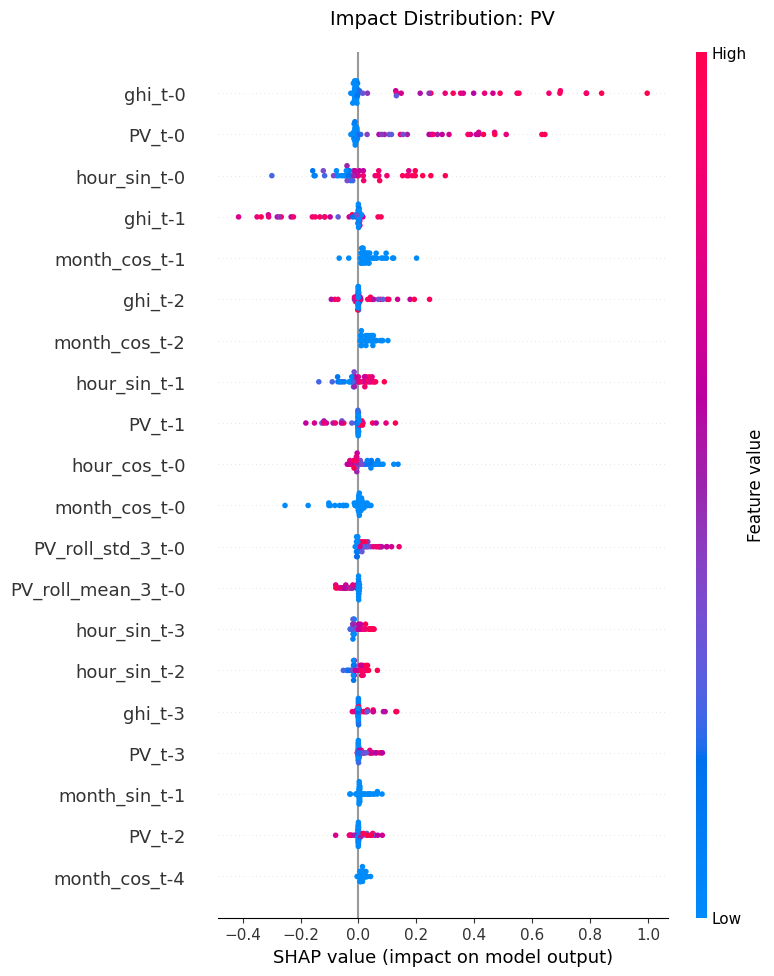

In [2]:

current_shap_raw = np.array(all_shap_dict[0])
s_flat, d_flat, names = get_flattened_data(current_shap_raw)
plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, show=False)
plt.title(f"Impact Distribution: PV", fontsize=14, pad=20)
plt.show()

### 2. Global Feature Importance
**What is this?** The mean absolute SHAP value for each feature.  
**What to focus on:** The length of the bar. It represents the "global" influence of a feature—how much it moves the prediction on average, regardless of direction.

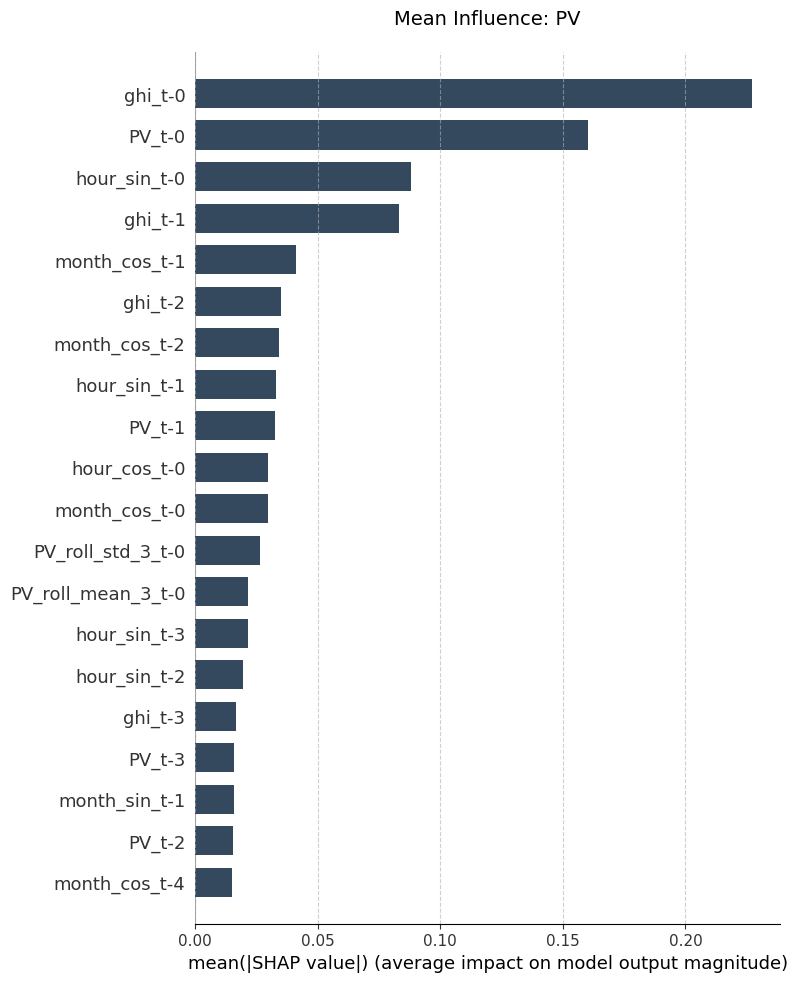

In [3]:

plt.figure(figsize=(10, 6))
shap.summary_plot(s_flat, d_flat, feature_names=names, plot_type='bar', show=False, color='#34495e')
plt.title(f"Mean Influence: PV", fontsize=14, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

### 3. Temporal Relevance
**What is this?** A look at which time-steps in the `6` window are most influential.  
**What to focus on:** Does the model care more about the immediate past (`t-0`, `t-1`) or older history? A peak at `t-0` suggests a reactive model; a peak at `t-5` suggests a dependency on long-term trends.

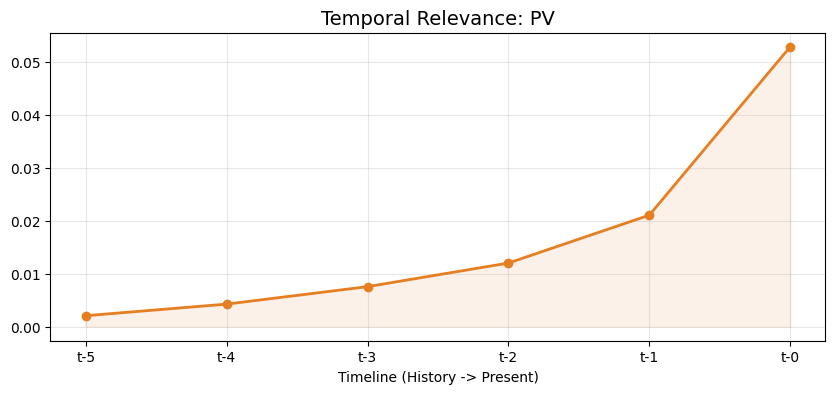

In [4]:

current_shap_raw = np.array(all_shap_dict[0])
importance_per_step = np.abs(current_shap_raw).mean(axis=(0, 2)).flatten()
time_labels = [f"t-{i}" for i in range(look_back-1, -1, -1)]
time_axis = list(range(len(time_labels)))

plt.figure(figsize=(10, 4))
plt.plot(time_axis, importance_per_step, marker='o', linewidth=2, color='#e67e22')
plt.xticks(time_axis, time_labels)
plt.title(f"Temporal Relevance: PV", fontsize=14)
plt.xlabel("Timeline (History -> Present)")
plt.fill_between(time_axis, importance_per_step, alpha=0.1, color='#e67e22')
plt.grid(True, alpha=0.3)
plt.show()

### 4. Focused View: Top 5 Drivers
**What is this?** A high-precision look at the five most critical variables for `PV`.  
**What to focus on:** The gap between the 1st and 5th feature. If the 1st is much larger, the model is heavily reliant on a single "smoking gun" variable.

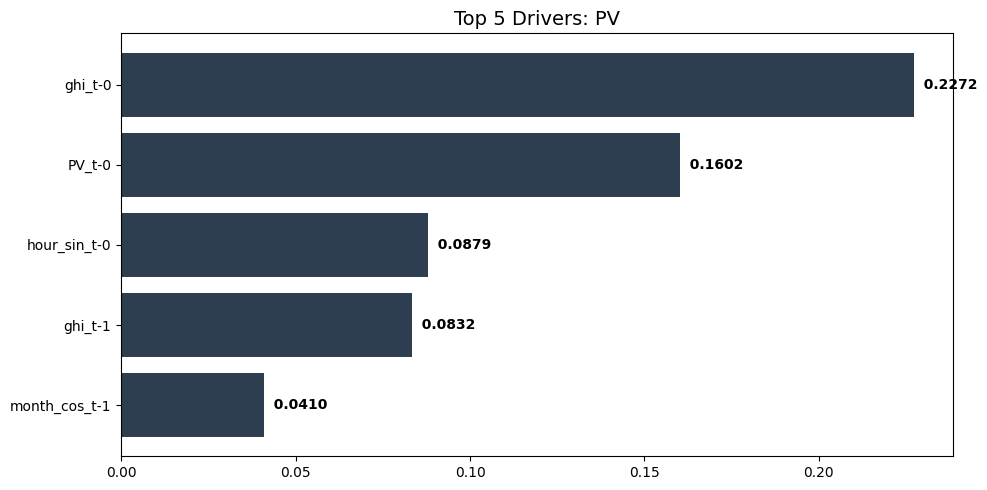

In [5]:

mean_shap = np.abs(s_flat).mean(axis=0)
sorted_idx = np.argsort(mean_shap)[-5:]
plt.figure(figsize=(10, 5))
plt.barh([names[i] for i in sorted_idx], mean_shap[sorted_idx], color='#2c3e50')
plt.title(f"Top 5 Drivers: PV", fontsize=14)
for i, v in enumerate(mean_shap[sorted_idx]):
    plt.text(v, i, f"  {v:.4f}", va='center', fontweight='bold')
plt.tight_layout()
plt.show()